# 01 Pyloric-Inspired Observation Engineering

This notebook extends the real SC4001 Sleep-EDF observation without changing `01_observation.ipynb`. It follows the scientific organization of the SBI Practical Guide pyloric example: rhythm speed, event duration, occupancy/duty cycle, relative event timing, and waveform morphology are treated as separately auditable observation coordinates.

Official references: [SBI Practical Guide Figure 10 pyloric workflow](https://github.com/sbi-dev/sbi-practical-guide/tree/main/paper/fig10_pyloric) and [pyloric summary statistics](https://github.com/mackelab/pyloric/blob/main/pyloric/summary_statistics.py).

**Scientific boundary.** This is observation engineering only. It runs no V7/V8 simulation, prior predictive check, NPE/NLE training, posterior inference, SBC, L-C2ST, or posterior predictive check. The 18D result is a feature library, not a frozen fitting vector.

> **学习注释版本说明**
>
> 本文件由 `01_Pyloric_Inspired_Observation.ipynb` 机械复制并增加中文学习注释。原始 code cells、执行顺序、execution count 和已有 outputs 均保持不变；本注释版不重新计算数据，也不改变 threshold、random seed、路径或算法。

## 学习导览：为什么叫 Pyloric-Inspired Observation？

Pyloric circuit 是一个经典的节律神经环路。它的研究常用少量、可解释的 summary 描述复杂时间序列，例如周期多快、一次 burst 持续多久、一个状态占周期多少比例、不同事件在周期中的相对相位，以及典型波形形态。本 notebook 借用的是这种**从高维轨迹提取低维节律结构**的思想，而不是把 pyloric neuron、burst 或其 18 维统计机械地移植到睡眠 EEG。

在这里，原始对象是 SC4001 的单通道 `EEG Fpz-Cz`。最终的 18D 是一个 **EEG observable summary library**：

1. spectral structure：频谱背景、SO 功率、峰频和选择性；
2. SO rhythm：事件速率、IBI 和节律规则性；
3. SO temporal morphology：可观测正/负相位的 duration proxy、duty cycle 和波形时间结构；
4. spindle：observable-channel spindle 的 density、duration 和 occupancy；
5. event-conditioned coordination：spindle onset 在 SO cycle 中的圆周相位。

### 它不是什么

- 它不是 posterior，也没有训练 NPE/NLE。
- 18 个字段不等于 18 个相互独立的拟合证据。rate 与 IBI、UP duty 与 UP/DOWN duration、spindle occupancy 与 density/duration 都存在确定性或近似派生关系。
- `held_out_ppc_candidate` 目前只能称作 **held-out predictive-check candidate / PPC-like candidate**。正式 posterior predictive check 必须先有经过验证的 posterior estimator，再从 posterior 采样参数并运行 simulator；本 notebook 没有做这些步骤。
- 单通道 scalp EEG 只能提供 observable-level 统计，不能直接观测 thalamic onset、cortex-thalamus propagation、directional latency 或 V7/V8 的 T9–T13 内部机制量。

### 三种角色怎样区分

| 角色 | 当前含义 | 能否直接进入 fitting？ |
|---|---|---|
| `inference_summary_candidate` | 在尺度、支持度和可解释性上值得进一步评估的 observation feature | 仍然不能；必须先做 simulator observable mapping、prior predictive support 和冗余筛选 |
| `held_out_ppc_candidate` | 更适合保留作独立预测检查的 observable feature | 当前只作 PPC-like/held-out 检查，避免用同一指标既拟合又验证 |
| `mechanism_diagnostic` | 帮助解释机制、算法或模型内部状态的量 | 不作为主要 observation fitting target；真实 EEG 不可观测的量保持无数值 |

### 阅读顺序

`Block 01–02` 建立环境并从真实 EEG 构建 observation；`Block 03–06` 定义 18D 字典与核心结果；`Block 07–08` 审计跨 epoch 稳定性和冗余；`Block 09–11` 解释 SO proxy、spindle 和 event-conditioned circular timing；`Block 12` 检查支持度与角色；`Block 13–15` 完成旧版回归、publication-safe 导出和最终验证。

## Runtime and reproducibility

The notebook must run in the existing `neurolib` Conda environment. It uses project-relative paths, records the configuration hash, requires `fooof==1.1.1`, and never installs or silently substitutes dependencies.

### Block 01 — Environment、路径、配置与可重复性入口

**科学目的：**  
在任何 EEG 计算前锁定“使用哪套代码、哪套环境、哪份配置”。这一步不产生生理结果，但决定后续结果能否复现。特别是 FOOOF 版本、随机种子和项目根路径若发生漂移，同一数据可能得到不同 summary 或把输出写到错误位置。

**主要输入：**
- 当前工作目录 `Path.cwd()`；
- 仓库结构 `S4_sbi/src/sleep_sbi/`；
- `observation_sc4001.yaml` 与 `pyloric_inspired_observation_sc4001.yaml`；
- 当前 Conda/Jupyter runtime 的 package metadata。

**处理逻辑：**
1. 从当前目录逐级向上寻找含 `S4_sbi/src/sleep_sbi` 的目录，将其定义为 `ROOT`。因此可从仓库根或子目录启动 notebook，不写死个人机器路径。
2. 把 `S4_sbi/src` 放到 `sys.path` 最前端，确保导入的是本仓库 `sleep_sbi`，不是其他同名安装包。
3. 导入原 Observation 构建函数和新增 Pyloric-inspired 分析/绘图 API。
4. 加载两层配置：`observation_config` 冻结数据、QC、PSD、SO、spindle、PAC；`pyloric_config` 只增加 cycle/pairing/stability 和输出设置。
5. `np.random.seed(...)` 固定任何需要确定性 tie-breaking 的过程；它不能消除数据和算法本身的不确定性。
6. 创建 publication-safe 输出目录，并记录配置 SHA-256。配置哈希相同意味着配置文件字节一致，不代表数据文件一定一致。
7. 断言 `CONDA_DEFAULT_ENV == "neurolib"` 和 `fooof==1.1.1`。版本不符会立即失败，禁止 silent fallback。

**关键输出与读法：**
- `runtime` 表：实际 Python executable、Conda 环境和关键依赖版本；
- `ROOT`、`OUTPUT_DIR`、`FIGURE_DIR`；
- `observation_config`、`pyloric_config`；
- `config_hash`：用于追踪本次分析设定。

正常输出应显示环境为 `neurolib`、FOOOF 为 `1.1.1`，输出路径为仓库内相对目录。若 assert 失败，不应跳过，因为后续数字将不再满足已验证的 observation contract。

**能说明什么 / 不能说明什么：**  
它能证明运行环境和代码路径满足约束；不能证明 EEG 标签、QC 或任何 18D 指标正确。环境一致是科学复现的必要条件，不是充分条件。

In [1]:
from pathlib import Path
import importlib.metadata as metadata
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
ROOT = next(
    (candidate for candidate in (cwd, *cwd.parents)
     if (candidate / 'S4_sbi' / 'src' / 'sleep_sbi').is_dir()),
    None,
)
if ROOT is None:
    raise RuntimeError('Run from the sleep_loop repository or one of its subdirectories')
SBI_SRC = ROOT / 'S4_sbi' / 'src'
if str(SBI_SRC) not in sys.path:
    sys.path.insert(0, str(SBI_SRC))

from sleep_sbi import build_observation_bundle, load_observation_config, map_raw_stage
from sleep_sbi.pyloric_inspired_observation import (
    CORE_FIELDS,
    build_pyloric_inspired_observation,
    load_pyloric_inspired_config,
    plot_concept_mapping,
    plot_event_pairing,
    plot_feature_distributions,
    plot_onset_phase_circular,
    plot_qc_audit,
    plot_redundancy_heatmap,
    plot_robust_variability,
    plot_role_map,
    plot_so_proxy_morphology,
    plot_spindle_detection,
    plot_support_and_missingness,
    save_figure,
    write_publication_safe_artifacts,
)

observation_config = load_observation_config()
pyloric_config = load_pyloric_inspired_config()
np.random.seed(pyloric_config.random_seed)
OUTPUT_DIR = ROOT / pyloric_config.artifact_output_dir
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
runtime = {
    'python_executable': sys.executable,
    'conda_environment': os.environ.get('CONDA_DEFAULT_ENV'),
    'python': sys.version.split()[0],
    **{name: metadata.version(name) for name in (
        'nbformat', 'nbclient', 'jupyter_core', 'ipykernel', 'numpy',
        'scipy', 'pandas', 'matplotlib', 'mne', 'fooof', 'neurolib'
    )},
}
assert runtime['conda_environment'] == 'neurolib', runtime
assert runtime['fooof'] == '1.1.1', runtime
display(pd.Series(runtime, name='runtime evidence').to_frame())
print('repository root:', ROOT)
print('output directory:', pyloric_config.artifact_output_dir)
print('config SHA-256:', pyloric_config.config_hash)

,runtime evidence
python_executable,c:\Users\YUS190\AppData\Local\anaconda3\envs\n...
conda_environment,neurolib
python,3.10.20
nbformat,5.10.4
nbclient,0.10.4
jupyter_core,5.9.1
ipykernel,7.2.0
numpy,2.2.6
scipy,1.15.2
pandas,2.3.3


repository root: D:\Year3_Mao_Projects\sleep_loop
output directory: S4_sbi/outputs/pyloric_inspired_observation
config SHA-256: 9e5f774daae2ac51e1215000129bd5b902e789aeef88e019d95a6c0faea71b25


## Scientific contract and source observation

The authoritative upstream contract remains the existing SC4001 pipeline: Sleep-EDF PSG plus hypnogram, Fpz-Cz at 100 Hz, native 30-second epochs, Stage 3 and Stage 4 mapped to N3, global N3 peak-to-peak QC at 200 uV, Hann Welch PSD, the existing per-epoch SO detector, provisional observable-channel spindle detector, and continuous PAC auxiliary diagnostics.

No non-contiguous epochs are concatenated before filtering, detection, IBI computation, cycle construction, or spindle-onset pairing. A metric-specific invalid epoch is not reclassified as globally rejected.

### Block 02 — 从 SC4001 EEG 构建 `ObservationBundle` 与 18D 结果

**科学目的：**  
执行完整真实 EEG observation 链路：加载 PSG/hypnogram、对齐 30 s epoch、标准化 stage、筛选 N3、做 global QC、计算原 Observation summaries，再构建新增的 18D、epoch ledger、支持度和回归表。

**主要输入：**
- `data/manifest.csv` 指向的 SC4001 PSG EDF 与 Hypnogram EDF；
- `observation_config`：Fpz-Cz、30 s、200 µV peak-to-peak 阈值、Hann Welch、SO/spindle/PAC 参数；
- `pyloric_config`：完整 SO cycle、event pairing 和稳定性审计规则。

**核心数据结构：**
- `bundle: ObservationBundle`：内存中保留 `(retained_epoch, sample)` 的 EEG segments、PSD、旧 summaries、provenance 与 detector diagnostics；
- `result: PyloricInspiredResult`：18D summary、per-epoch features、完整 epoch ledger、feature dictionary、auxiliary diagnostics、Spearman/support、旧版回归和 validation checks。

**数据与 QC 流程：**
1. PSG 按原生 30 s 网格切分，hypnogram annotation 对齐到相同网格。
2. `Sleep stage 3`、`Sleep stage 4` 以及短标签 `"3"` 显式映射到 N3；短标签测试防止历史上 `"3"` 被错误归为 N2。
3. global QC 只作用于 N3。当前主要规则是 peak-to-peak amplitude 不超过 200 µV，同时拒绝非有限或近乎平坦的 epoch。
4. retained N3 才进入后续 PSD 和 detector；但某个 retained epoch 可对 PSD 有效、对 IBI 无效。这叫 metric-specific invalid，不会把它重新改成 global rejection。

必须满足：

$$
N_{\mathrm{retained\ N3}}+N_{\mathrm{rejected\ N3}}
=N_{\mathrm{all\ N3}}.
$$

retained/rejected 集合还必须互斥，每个 rejected epoch 必须有 reason。non-N3 没有进入 N3 QC 的资格，因此不能错误计入 rejection。

**四种容易混淆的状态：**
- `global QC rejection`：整段 N3 EEG 因原始信号质量不合格，不进入任何后续指标；
- `metric-specific invalid`：epoch 全局保留，但对某个指标事件或数值支持不足；
- `0 detected events`：detector 正常运行并确认该 epoch 没有事件；rate/density 可以是 0；
- `metric undefined`：例如 0 spindle 时 mean duration 没有定义，必须是 NaN，而不是 0。

**输出怎样阅读：**
- 当前执行结果应接近 `2650 aligned / 220 N3 / 142 retained / 78 rejected`，但这些数字来自实际数据，不能硬编码；
- `raw_label_counts` 是 annotation 中实际 label occurrence 的审计，不要把 annotation occurrence count 与展开后的 30 s epoch count 混为一谈；
- channel 为 `EEG Fpz-Cz`，采样率 100 Hz，幅值单位 µV，reference 是双极 Fpz-Cz derivation。

**warning/NaN 的含义：**  
FOOOF warning 可提示包弃用但版本仍锁定；detector warning 表示某些 epoch 或算法仍属 provisional。NaN 必须结合对应 validity mask 和 invalid reason 阅读，不能静默过滤后假装所有 epoch 都有支持。

**科学边界：**  
本 block 构建的是 observation summary，不运行 simulator，也不产生 posterior。`bundle.validate()` 和 accounting asserts 验证结构一致性，不等同于证明所有指标具有生理特异性。

In [2]:
bundle = build_observation_bundle(observation_config)
bundle.validate()
result = build_pyloric_inspired_observation(
    bundle, observation_config, pyloric_config
)
assert map_raw_stage('Sleep stage 3') == 'N3'
assert map_raw_stage('Sleep stage 4') == 'N3'
assert map_raw_stage('3') == 'N3'
epoch_accounting = pd.Series({
    'aligned_30s_epochs': len(bundle.diagnostics['mapped_stages']),
    'all_N3_epochs': len(bundle.n3_epoch_indices),
    'retained_N3_epochs': len(bundle.retained_epoch_indices),
    'rejected_N3_epochs': len(bundle.rejected_epoch_indices),
})
assert epoch_accounting['retained_N3_epochs'] + epoch_accounting['rejected_N3_epochs'] == epoch_accounting['all_N3_epochs']
display(epoch_accounting.to_frame('count'))
display(pd.Series(bundle.raw_label_counts, name='annotation occurrence count').to_frame())
print('channel:', bundle.channel, '| fs:', bundle.fs_hz, 'Hz | unit: uV')
print('reference:', bundle.provenance['reference'])

D:\Year3_Mao_Projects\sleep_loop\S4_sbi\src\sleep_sbi\observation.py:117: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


,count
aligned_30s_epochs,2650
all_N3_epochs,220
retained_N3_epochs,142
rejected_N3_epochs,78


,annotation occurrence count
Sleep stage 1,24
Sleep stage 2,40
Sleep stage 3,48
Sleep stage 4,23
Sleep stage ?,1
Sleep stage R,6
Sleep stage W,12


channel: EEG Fpz-Cz | fs: 100.0 Hz | unit: uV
reference: bipolar derivation Fpz-Cz as recorded; no additional re-reference applied


## Concept mapping: pyloric timing concepts to EEG observables

The mapping below is conceptual, not a claim that scalp EEG equals pyloric membrane voltage or the cortical-thalamic simulator's internal states. The feature dictionary fixes field names, units, frequency bands, algorithms, aggregation, role, and known dependency.

### Block 03 — 统一绘图/保存契约与 18D feature dictionary

**工程目的：**  
定义所有图共用的 `render_and_save(...)`：每张图独立调用 plotter、立即显示、保存 PNG/PDF、关闭 Matplotlib figure，并把 publication-safe metadata 登记到 `figure_records`。关闭 figure 只释放绘图资源，不删除 notebook 中已经显示的图。

**输入与输出：**
- 输入：`figure_id`、绘图函数 `plotter`、该图所需数据；
- plotter 返回 `fig` 与不含原始 EEG array 的 `safe_metadata`；
- 输出文件位于 `FIGURE_DIR`，manifest 只记录相对路径；
- `result.feature_dictionary` 是稳定的 18 行定义表，包含单位、频带、算法、aggregation、依赖关系和推荐角色。

## 18D 指标逐项学习

### A. Spectral structure

1. **`fooof_aperiodic_exponent`，单位 1，inference candidate**  
   FOOOF 在 0.5–20 Hz 将功率谱近似分为 aperiodic background 与 peaks。直观形式为 $P(f)\propto 1/f^\chi$，$\chi$ 即 exponent。它描述频谱背景斜率，可能对整体网络时间尺度、兴奋/抑制平衡或状态深度敏感，但不是某个单一机制的专属读出。本实现拟合 retained-epoch Hann PSD 的算术平均。
2. **`relative_so_power`，单位 1，inference candidate**  
   配置定义为 SO band（0.2–1.5 Hz）积分功率相对 analysis band（0.5–20 Hz）积分功率。比值减弱绝对电压尺度影响，但仍受 reference、滤波、谱泄漏和 aperiodic slope 影响。
3. **`so_peak_frequency_hz`，单位 Hz，inference candidate**  
   在 SO band 内寻找 aggregate Hann PSD 最大频点。Welch 分辨率为 0.25 Hz，因此 `0.5 Hz` 是离散 frequency-bin 结果，不应报告成无限精度的真实振荡频率。
4. **`so_q`，单位 1，inference candidate**  
   计算 SO peak PSD 与相邻背景 band mean PSD 的比值，用来表达谱峰相对突出程度。它不是严格物理振荡器的 quality factor，也会与 relative SO power、aperiodic background 相关。

### B. SO rhythm

5. **`so_event_rate_per_min`，单位 events/min，inference candidate**  
   有效 retained N3 中检测到的 SO events 总数除以有效分钟数。它对 SO detector threshold、波形幅值和节律速度都敏感。
6. **`so_median_ibi_s`，单位 s，inference candidate**  
   IBI 是同一 30 s epoch 内相邻 SO events 的时间差。先求每个有效 epoch 的 median IBI，再跨 epoch 求 median，以降低长间隔和 event-rich epoch 对 aggregate 的支配。
7. **`ibi_cv`，单位 1，inference candidate**  
   定义为

   $$
   \mathrm{IBI\_CV}=\frac{\mathrm{SD}(\mathrm{IBI})}
   {\mathrm{Mean}(\mathrm{IBI})}.
   $$

   CV 将间隔波动相对平均间隔标准化：接近 0 表示事件间隔较规则，较大值表示节律不规则。它需要至少两个 within-epoch intervals；事件不足时是 undefined，不是“规则性为 0”。

对于近似规则的节律：

$$
\mathrm{SO\ rate\ (events/min)}\approx\frac{60}{\mathrm{IBI\ (s)}}.
$$

因此 rate 与 IBI 不是两份完全独立证据。

### C. SO temporal morphology

8. **`so_up_proxy_duration_s`，单位 s，inference candidate**：接受的 SO trough 后，紧邻 EEG 正相位的零交叉持续时间；对波形时间结构敏感。  
9. **`so_down_proxy_duration_s`，单位 s，inference candidate**：围绕 trough 的紧邻 EEG 负相位持续时间。  
10. **`so_up_proxy_duty_cycle`，单位 1，held out**：

   $$
   D_{\mathrm{UP-proxy}}=
   \frac{T_{\mathrm{UP-proxy}}}
   {T_{\mathrm{UP-proxy}}+T_{\mathrm{DOWN-proxy}}}.
   $$

   它由两个 duration 确定性派生，不能当作第三份独立证据。
11. **`waveform_peak_to_peak_z`，单位 z，held out**  
   每个 trough-centered waveform 先在自身窗口 z-score，再对齐求 mean waveform，最后取其 peak-to-peak。它描述尺度归一化后的形态幅度，不是 µV，也不能解释绝对 EEG 强度。
12. **`so_trough_to_peak_time_s`，单位 s，held out**  
   完整有效 cycle 中检测 trough 到随后 peak 的时间，描述一个周期内部的上升时序。它与正/负相位 duration 存在结构关联。

这里的 UP/DOWN 只是 **as-recorded Fpz-Cz positive/negative phase proxy**。scalp polarity 受 montage 和 reference 影响，不能无条件等同于神经元膜电位 UP/DOWN state，更不能直接与 simulator internal state duration 比较。

### D. Observable spindle

13. **`spindle_density_per_min`，events/min，held out/provisional**：有效时间内 spindle event 数；0-event 有效 epoch 可取 0。  
14. **`spindle_mean_duration_s`，s，held out/provisional**：检测到的 events 平均持续时间；0 events 时必须 NaN。  
15. **`spindle_occupancy`，1，held out/provisional**：spindle intervals 的 union duration 除以 detector-valid observation duration。合并重叠区间防止重复计时。

若 density 使用 events/s，则 occupancy 近似为 density × duration；当前 density 单位为 events/min，量纲一致的近似是：

$$
\mathrm{occupancy}\approx
\frac{\mathrm{density\ (events/min)}\times
\mathrm{mean\ duration\ (s)}}{60}.
$$

因此 density、duration、occupancy 不能视作三份完全独立证据。

### E. Event-conditioned SO–spindle coordination

16. **`spindle_onset_phase_cos`，单位 1，held out/provisional**；  
17. **`spindle_onset_phase_sin`，单位 1，held out/provisional**；  
18. **`spindle_onset_phase_concentration`，单位 1，held out/provisional**。

phase 是圆周变量：$0$ 与 $2\pi$ 表示同一方向，普通线性平均会把接近 $0$ 和 $2\pi$ 的事件错误平均到 $\pi$。因此用复数向量 $e^{i\theta}$ 计算 circular mean，并用 `cos(mean phase)`、`sin(mean phase)` 编码方向。cos/sin 是同一个角度的两个坐标，满足 $\cos^2\theta+\sin^2\theta=1$，不是两个独立生理证据。raw angle 只保留在 auxiliary table，不能与 sin/cos 一起重复计入 18D。

concentration 为 resultant vector length：
- $R\approx 1$：onset phase 高度集中；
- $R\approx 0$：相位分散或近似均匀。

注意 $R=0$ 是“有足够事件但相位分散”的结果；事件数量不足时 circular statistic 应为 undefined/warning，不能填 0。若 continuous PAC MI 极弱，preferred phase 也可能随噪声和 band/filter 选择大幅变化，不能被解释为稳定生理靶点。

**本 cell 的读法：**  
当前只显示 feature dictionary，不显示最终被试 aggregate 数值；Block 06 才显示 `result.summary`。字典中的 intended role 是设计决策提示，不是已经冻结的 fitting contract。

In [3]:
figure_records = []

def render_and_save(figure_id, plotter, *args):
    fig, safe_metadata = plotter(*args)
    paths = save_figure(fig, FIGURE_DIR, figure_id, pyloric_config.artifact_dpi)
    display(fig)
    plt.close(fig)
    record = {
        'figure_id': figure_id,
        'png': f"figures/{paths['png']}",
        'pdf': f"figures/{paths['pdf']}",
        'metadata': safe_metadata,
    }
    figure_records.append(record)
    return safe_metadata

display(result.feature_dictionary)

,field_name,domain,pyloric_analogy,unit,frequency_band,algorithm,aggregation_method,intended_role,dependency_or_redundancy
0,fooof_aperiodic_exponent,spectral_structure,baseline state/shape,1,0.5-20 Hz,FOOOF 1.1.1 fixed aperiodic fit,fit to arithmetic-mean Hann epoch PSD,inference_summary_candidate,spectral baseline; may covary with relative SO...
1,relative_so_power,spectral_structure,relative state strength,1,0.2-1.5 Hz / 0.5-20 Hz,trapezoidal power ratio from Hann Welch PSD,ratio from arithmetic-mean retained-epoch PSD,inference_summary_candidate,related to SO Q and aperiodic exponent
2,so_peak_frequency_hz,spectral_structure,rhythm speed,Hz,0.2-1.5 Hz,maximum of aggregate Hann Welch PSD in SO band,arithmetic-mean retained-epoch PSD,inference_summary_candidate,frequency-bin resolution limited
3,so_q,spectral_structure,rhythm selectivity,1,0.2-1.5 Hz,SO peak PSD / adjacent-band mean PSD,computed from aggregate Hann PSD,inference_summary_candidate,related to relative SO power
4,so_event_rate_per_min,so_rhythm,cycle frequency,events/min,0.2-4 Hz detector,existing DOWN-to-UP half-wave detector,events / valid retained-N3 minutes,inference_summary_candidate,approximately 60 / median IBI for regular rhythms
5,so_median_ibi_s,so_rhythm,cycle period,s,0.2-4 Hz detector,within-epoch UP-event intervals,median of per-epoch median IBI values,inference_summary_candidate,inverse relationship with SO event rate
6,ibi_cv,so_rhythm,cycle regularity,1,0.2-4 Hz detector,CV of within-epoch UP-event intervals,all valid within-epoch intervals pooled; no bo...,inference_summary_candidate,depends on event count and median IBI
7,so_up_proxy_duration_s,so_temporal_morphology,state duration,s,0.2-4 Hz detector,positive-phase zero-crossing duration around a...,median of per-epoch medians over complete cycles,inference_summary_candidate,EEG observable proxy; not model cortical UP state
8,so_down_proxy_duration_s,so_temporal_morphology,state duration,s,0.2-4 Hz detector,negative-phase zero-crossing duration around a...,median of per-epoch medians over complete cycles,inference_summary_candidate,EEG observable proxy; not model cortical DOWN ...
9,so_up_proxy_duty_cycle,so_temporal_morphology,duty cycle,1,0.2-4 Hz detector,UP-proxy / (UP-proxy + DOWN-proxy),median of per-epoch medians over complete cycles,held_out_ppc_candidate,deterministic function of paired proxy durations


### Block 04 — Pyloric concept 到 EEG 18D 的 mapping 图

**科学问题：**  
Pyloric rhythm summary 的哪些抽象概念被转译为 EEG observable，而不是照搬具体 neuron/burst 指标？

**输入与调用：**  
`plot_concept_mapping(result.feature_dictionary)` 按 feature domain 和 `pyloric_analogy` 组织 18 个字段；`render_and_save` 显示并导出 `01_concept_mapping.png/pdf`，同时返回 metadata。

**图怎样阅读：**
- 行是 EEG feature domain 与其 pyloric-inspired 概念，例如 rhythm speed、state duration、duty/occupancy、relative phase；
- EEG 字段列列出具体 SC4001 observable；
- `n` 表示该概念映射到的字段数量，不是 epoch 或 event sample size；
- 这是一张语义 mapping table，没有数值横纵轴，也不显示拟合优劣。

**正常/异常模式：**  
正常情况下 18 个字段应全部且只出现一次。若字段缺失或重复，说明 feature dictionary 与冻结的 `CORE_FIELDS` 不一致，后续 schema assertion 会失败。

**能说明什么 / 不能说明什么：**  
它能说明设计覆盖了速度、持续时间、占空比、相对时序和形态；不能证明这些 EEG features 与 pyloric statistics 生理同源，也不能证明 simulator 能生成这些 observable。表格不是 Figure 10 posterior panel。

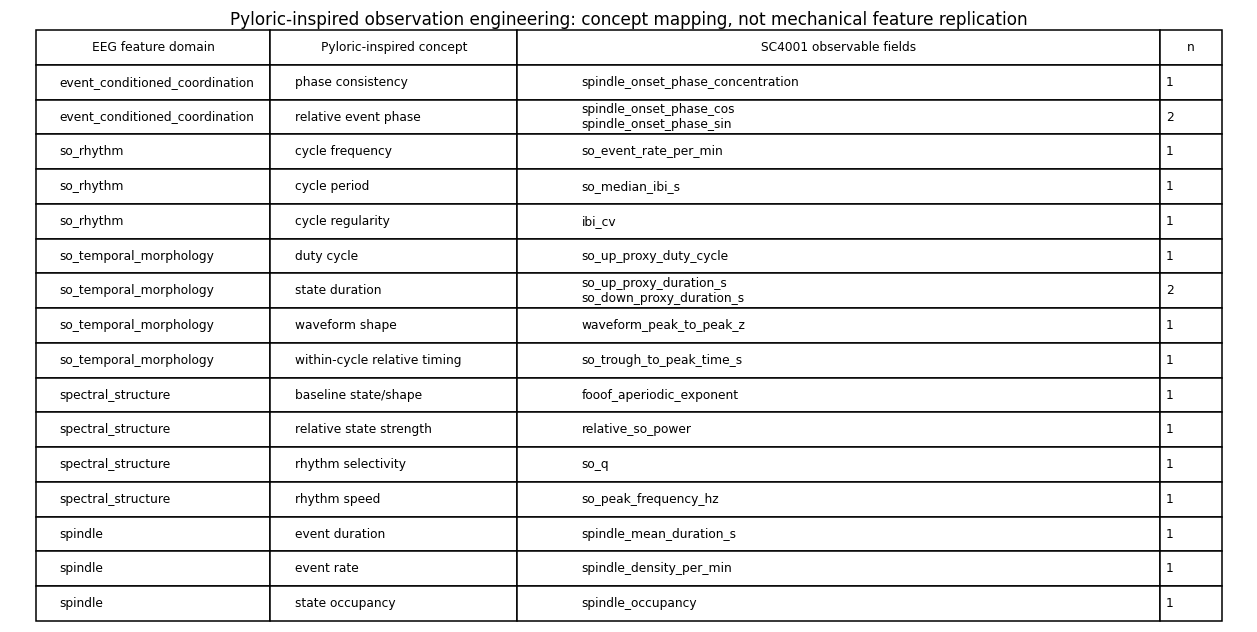

{'figure_id': 'concept_mapping',
 'mapping_rows': [{'domain': 'event_conditioned_coordination',
   'pyloric_analogy': 'phase consistency',
   'eeg_fields': 'spindle_onset_phase_concentration',
   'count': 1},
  {'domain': 'event_conditioned_coordination',
   'pyloric_analogy': 'relative event phase',
   'eeg_fields': 'spindle_onset_phase_cos\nspindle_onset_phase_sin',
   'count': 2},
  {'domain': 'so_rhythm',
   'pyloric_analogy': 'cycle frequency',
   'eeg_fields': 'so_event_rate_per_min',
   'count': 1},
  {'domain': 'so_rhythm',
   'pyloric_analogy': 'cycle period',
   'eeg_fields': 'so_median_ibi_s',
   'count': 1},
  {'domain': 'so_rhythm',
   'pyloric_analogy': 'cycle regularity',
   'eeg_fields': 'ibi_cv',
   'count': 1},
  {'domain': 'so_temporal_morphology',
   'pyloric_analogy': 'duty cycle',
   'eeg_fields': 'so_up_proxy_duty_cycle',
   'count': 1},
  {'domain': 'so_temporal_morphology',
   'pyloric_analogy': 'state duration',
   'eeg_fields': 'so_up_proxy_duration_s\nso_dow

In [4]:
concept_metadata = render_and_save(
    '01_concept_mapping', plot_concept_mapping, result.feature_dictionary
)
display(concept_metadata)

## Epoch ledger and QC audit

Global QC is applied only to N3 epochs. The panel shows retained/rejected peak-to-peak distributions, the frozen threshold, rejection reasons, deterministic median-PTP waveform examples, and metric-specific support. The ledger assigns every aligned epoch exactly one global status.

### Block 05 — Epoch ledger、global QC 与 metric-specific support

**科学目的：**  
把每个对齐 epoch 的去向做成可审计账本，区分 N3 global rejection 与 retained epoch 内的 metric-specific missingness，并用图检查 200 µV peak-to-peak 阈值是否按预期分离数据。

**代码做什么：**
1. `global_qc_status.value_counts()` 统计 `retained`、`rejected` 与 `not_applicable_non_n3`；
2. 只对 rejected rows 统计 `rejection_reasons`；
3. 显示 ledger 前几行，检查 raw label、AASM stage、global status、各 metric validity 和 event count 同时存在；
4. `plot_qc_audit(...)` 生成多 panel QC 图及安全 metadata。

**图表逐 panel 阅读：**
- **Epoch accounting**：纵轴是 30 s epoch 数，显示 aligned、N3、retained、rejected；当前约为 2650、220、142、78。aligned 远大于 N3 是正常的整夜睡眠结构，不是拒绝率。
- **N3 peak-to-peak QC**：横轴 µV，纵轴 epoch count；绿色 retained、红色 rejected，黑色虚线为 200 µV。threshold 左右应与 retained/rejected 基本一致。
- **Rejection reasons**：横轴 epoch count；当前 78 个均为 `peak_to_peak_above_threshold`。若出现 `non_finite_samples` 或 `near_flat_signal`，应单独追踪。
- **Metric-specific valid support**：横轴是 retained N3 epoch 数，虚线为全部 retained。PSD 可覆盖所有 retained，而 IBI、完整 SO proxy、spindle duration 和 event pairing 可少于 142。
- **Representative waveforms**：横轴是 epoch 内时间 0–30 s，纵轴为 Fpz-Cz µV；绿色/红色分别是可重复选择的 retained/rejected median-PTP 示例。单一示例帮助检查尺度，但不能代表整类 epoch。

**关键恒等式与集合逻辑：**

$$
N_{\mathrm{retained}}+N_{\mathrm{rejected}}=N_{\mathrm{N3}},
\qquad
\mathrm{retained}\cap\mathrm{rejected}=\varnothing.
$$

non-N3 的 status 应是 `not_applicable_non_n3`，因为它没有进入 N3 QC；把 non-N3 计为 rejection 会把睡眠结构误当作数据质量问题。

**四类数值状态再次区分：**
- rejected：原始 epoch 整体不用；
- retained but metric invalid：其他指标仍可用；
- valid detector + zero events：event rate 可真实为 0；
- event count insufficient：IBI、mean duration 或 circular metric undefined，必须保留 NaN/reason。

**Reviewer note / Potential issue：**  
200 µV 是当前项目冻结的兼容阈值，不代表所有受试者、montage 或仪器的通用最佳阈值。该图能审计阈值如何作用，不能独立证明阈值已完成跨数据集验证。

,epoch_count
global_qc_status,
not_applicable_non_n3,2430
retained,142
rejected,78


,rejected_epoch_count
rejection_reasons,
peak_to_peak_above_threshold,78


,epoch_index,raw_label,aasm_stage,is_n3,global_qc_status,rejection_reasons,psd_valid,fooof_valid,so_detector_valid,ibi_valid,so_proxy_valid,waveform_valid,spindle_detector_valid,spindle_duration_valid,event_pairing_valid,so_event_count,ibi_interval_count,so_proxy_cycle_count,spindle_event_count,paired_event_count
0,0,Sleep stage W,W,False,not_applicable_non_n3,,False,False,False,False,False,False,False,False,False,0,0,0,0,0
1,1,Sleep stage W,W,False,not_applicable_non_n3,,False,False,False,False,False,False,False,False,False,0,0,0,0,0
2,2,Sleep stage W,W,False,not_applicable_non_n3,,False,False,False,False,False,False,False,False,False,0,0,0,0,0
3,3,Sleep stage W,W,False,not_applicable_non_n3,,False,False,False,False,False,False,False,False,False,0,0,0,0,0
4,4,Sleep stage W,W,False,not_applicable_non_n3,,False,False,False,False,False,False,False,False,False,0,0,0,0,0


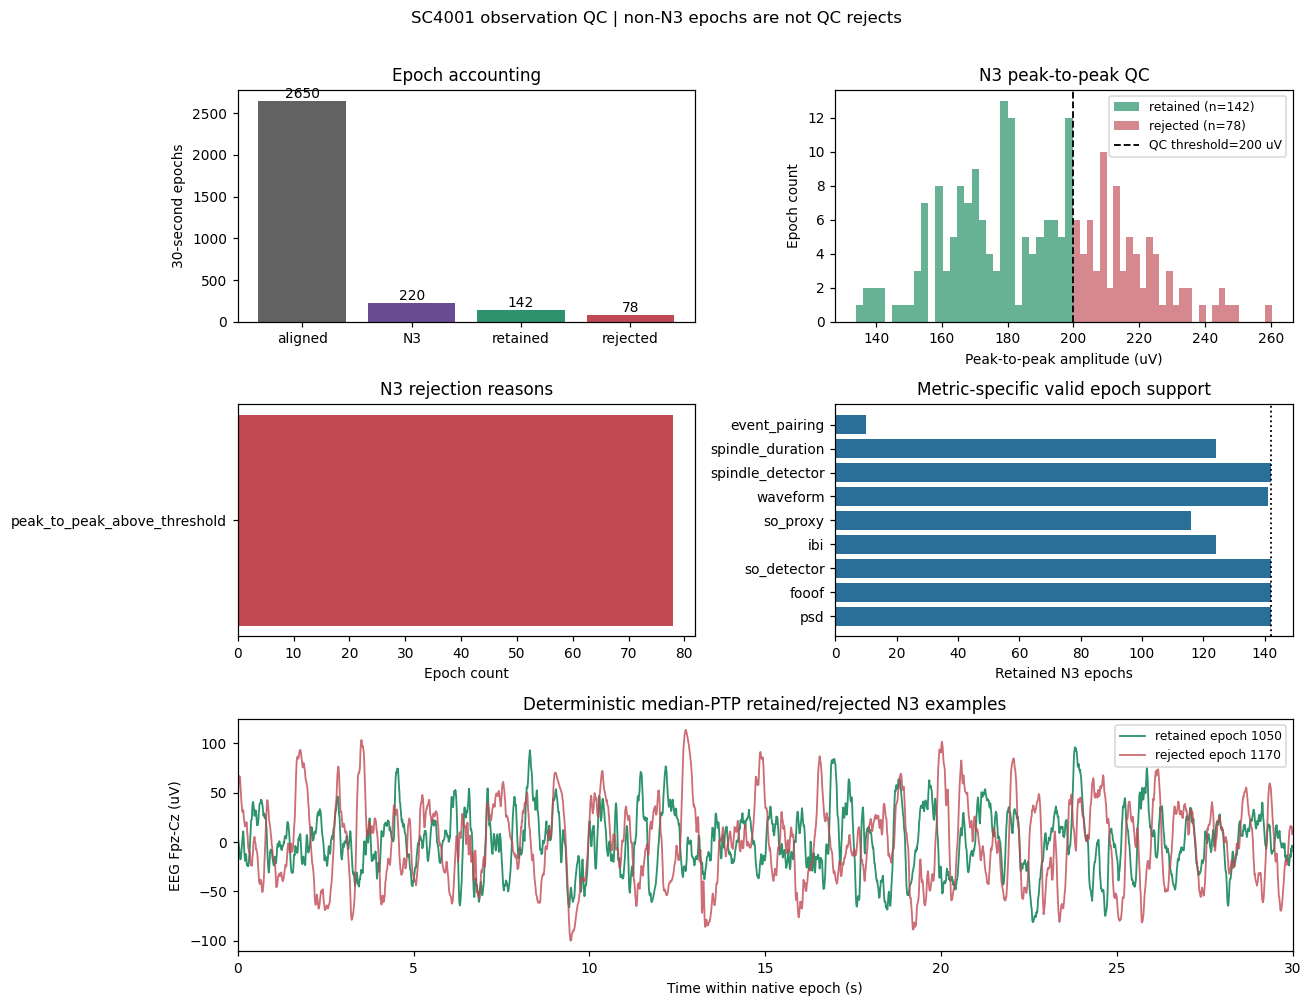

{'figure_id': 'epoch_qc_audit',
 'epoch_counts': {'aligned': 2650, 'N3': 220, 'retained': 142, 'rejected': 78},
 'rejection_reason_counts': {'peak_to_peak_above_threshold': 78},
 'metric_support': {'psd_valid': 142,
  'fooof_valid': 142,
  'so_detector_valid': 142,
  'ibi_valid': 124,
  'so_proxy_valid': 116,
  'waveform_valid': 141,
  'spindle_detector_valid': 142,
  'spindle_duration_valid': 124,
  'event_pairing_valid': 10},
 'representative_retained_epoch': 1050,
 'representative_rejected_epoch': 1170,
 'qc_threshold_uv': 200.0}

In [5]:
ledger_counts = result.epoch_ledger['global_qc_status'].value_counts()
reason_counts = (
    result.epoch_ledger.loc[result.epoch_ledger['global_qc_status'].eq('rejected'), 'rejection_reasons']
    .value_counts()
)
display(ledger_counts.to_frame('epoch_count'))
display(reason_counts.to_frame('rejected_epoch_count'))
display(result.epoch_ledger.head())
qc_metadata = render_and_save(
    '02_epoch_qc_audit', plot_qc_audit, bundle, result, observation_config
)
display(qc_metadata)

## Core Pyloric-inspired 18D library

Nine fields are `inference_summary_candidate`, each explicitly marked candidate-only and not frozen into fitting. Nine are `held_out_ppc_candidate`; because no posterior estimator exists, these are more precisely PPC-like predictive-check candidates. Undefined metrics remain NaN with warnings. Zero detected spindle events yield zero density/occupancy but undefined mean duration.

### Block 06 — 冻结 18D schema、显示 aggregate 数值与角色

**科学目的：**  
将 Block 03 的定义落实为一个恰好 18 行的 subject-level observation summary，并阻止字段重复、漏项或顺序漂移。

**代码逻辑：**
- `tuple(result.summary['field_name']) == CORE_FIELDS`：字段内容和顺序必须完全等于冻结 contract；
- `is_unique` 与 `len==18`：防止同名字段重复和维数漂移；
- 显示完整 summary table 及 intended-role counts。

**summary table 列怎样阅读：**
- `value`：SC4001 aggregate；NaN 只在指标 undefined 时出现；
- `unit` 与 `frequency_band`：解释数值量纲，不能跨不同单位直接比较大小；
- `algorithm`、`aggregation_method`：说明数值从 EEG 如何产生；
- `valid_epoch_count`、`valid_event_count`：这是证据支持度，不是置信区间；
- `validity_status`：`valid`、`provisional` 或 `invalid`；
- `intended_role`：inference candidate 或 held-out candidate；
- `dependency_or_redundancy`、`warnings`：提醒派生关系和科学限制。

当前结果中 9 项为 `inference_summary_candidate`，9 项为 `held_out_ppc_candidate`。这只是角色平衡，不说明两组各自内部独立或同等可靠。

**怎样判断正常结果：**
- spectral/rhythm/proxy/duration 均应为有限值或带明确 invalid reason；
- duty cycle、occupancy、concentration 必须在 `[0,1]`；
- rate 使用 events/min、duration 使用 s、frequency 使用 Hz；
- `spindle_onset_phase_cos/sin` 可为负数，这是圆周方向坐标，不是非法值；
- `valid_event_count` 较低时，即使 aggregate 有数值，也应降低解释强度。

**能说明什么 / 不能说明什么：**  
这张表说明 SC4001 在当前算法和配置下的 observation coordinates；不能说明它们已经进入 SBI fitting，也不能从一个 subject-level value 推断群体生理规律。所有 inference 字段仍有统一 warning：`Candidate only - not yet frozen into fitting.`

In [6]:
assert tuple(result.summary['field_name']) == CORE_FIELDS
assert result.summary['field_name'].is_unique and len(result.summary) == 18
display(result.summary)
display(result.summary['intended_role'].value_counts().to_frame('feature_count'))

,field_name,value,unit,frequency_band,algorithm,aggregation_method,valid_epoch_count,valid_event_count,validity_status,intended_role,dependency_or_redundancy,warnings
0,fooof_aperiodic_exponent,2.558807,1,0.5-20 Hz,FOOOF 1.1.1 fixed aperiodic fit,fit to arithmetic-mean Hann epoch PSD,142,NaN,valid,inference_summary_candidate,spectral baseline; may covary with relative SO...,Candidate only - not yet frozen into fitting.
1,relative_so_power,0.777428,1,0.2-1.5 Hz / 0.5-20 Hz,trapezoidal power ratio from Hann Welch PSD,ratio from arithmetic-mean retained-epoch PSD,142,NaN,valid,inference_summary_candidate,related to SO Q and aperiodic exponent,Candidate only - not yet frozen into fitting.
2,so_peak_frequency_hz,0.500000,Hz,0.2-1.5 Hz,maximum of aggregate Hann Welch PSD in SO band,arithmetic-mean retained-epoch PSD,142,NaN,valid,inference_summary_candidate,frequency-bin resolution limited,Candidate only - not yet frozen into fitting. ...
3,so_q,4.869293,1,0.2-1.5 Hz,SO peak PSD / adjacent-band mean PSD,computed from aggregate Hann PSD,142,NaN,valid,inference_summary_candidate,related to relative SO power,Candidate only - not yet frozen into fitting.
4,so_event_rate_per_min,13.112676,events/min,0.2-4 Hz detector,existing DOWN-to-UP half-wave detector,events / valid retained-N3 minutes,142,931.0,valid,inference_summary_candidate,approximately 60 / median IBI for regular rhythms,Candidate only - not yet frozen into fitting.
5,so_median_ibi_s,2.452500,s,0.2-4 Hz detector,within-epoch UP-event intervals,median of per-epoch median IBI values,124,790.0,valid,inference_summary_candidate,inverse relationship with SO event rate,Candidate only - not yet frozen into fitting. ...
6,ibi_cv,1.011715,1,0.2-4 Hz detector,CV of within-epoch UP-event intervals,all valid within-epoch intervals pooled; no bo...,124,779.0,valid,inference_summary_candidate,depends on event count and median IBI,Candidate only - not yet frozen into fitting. ...
7,so_up_proxy_duration_s,0.606530,s,0.2-4 Hz detector,positive-phase zero-crossing duration around a...,median of per-epoch medians over complete cycles,116,322.0,valid,inference_summary_candidate,EEG observable proxy; not model cortical UP state,Candidate only - not yet frozen into fitting. ...
8,so_down_proxy_duration_s,0.611617,s,0.2-4 Hz detector,negative-phase zero-crossing duration around a...,median of per-epoch medians over complete cycles,116,322.0,valid,inference_summary_candidate,EEG observable proxy; not model cortical DOWN ...,Candidate only - not yet frozen into fitting. ...
9,so_up_proxy_duty_cycle,0.487025,1,0.2-4 Hz detector,UP-proxy / (UP-proxy + DOWN-proxy),median of per-epoch medians over complete cycles,116,322.0,valid,held_out_ppc_candidate,deterministic function of paired proxy durations,Held-out predictive-check candidate; no formal...


,feature_count
intended_role,
inference_summary_candidate,9
held_out_ppc_candidate,9


## Feature distributions and robust variability

Native-unit distributions retain physiological scale. The second panel uses per-feature median/IQR normalization only to compare cross-epoch variability; normalized magnitude must not be interpreted as equal absolute physiological strength.

### Block 07 — 18D per-epoch distributions 与 robust variability

**科学目的：**  
aggregate value 会隐藏跨 epoch 异质性。本 block 同时展示每个 feature 的 native-unit 分布和 robust-normalized variability，并输出稳定性审计表。

**第一张图：native-unit distributions**
- 每个小图横轴是该指标自己的物理单位，纵轴是具有有限值的 epoch count；
- 黑色虚线是 median；
- 标题下的 finite `n` 反映 metric-specific support；
- 分布偏斜、多峰或长尾提示 aggregate 可能依赖少数 epoch，不能只读 subject median。

例如 spindle mean duration 在 zero-event epoch 为 NaN，因此其有限样本数少于 spindle density；phase coordinates 需要每 epoch 至少两个配对事件，有限样本会更少。

**第二张图：robust-normalized variability**

每个指标分别计算：

$$
z_{\mathrm{robust}}=\frac{x-\mathrm{median}(x)}
{\mathrm{IQR}(x)}.
$$

箱线图适合比较“相对自身典型 spread 的跨 epoch 变化”。它不保留原始单位，因此**不能**据此声称某个 z 值更大的指标具有更强绝对生理振幅，也不能把 Hz、s、events/min 和无量纲量视作同一物理尺度。

**`stability_audit` 输出：**
- `finite_epoch_count` / `missing_fraction`：支持度；
- median、quartiles、IQR：稳健中心与 spread；
- `robust_outlier_sensitivity`：mean 与 median 相对 IQR 的差异；
- `near_constant`：几乎没有跨 epoch 信息的字段；
- `redundant_with`、`recommendation`：结合相关与角色给出初步建议。

**NaN 与 warning：**  
NaN 在绘图前显式过滤，finite `n` 必须同时显示。过滤 NaN 是为了画有效分布，不代表缺失被“解决”；缺失比例会在 support panel 和 audit table 中继续保留。

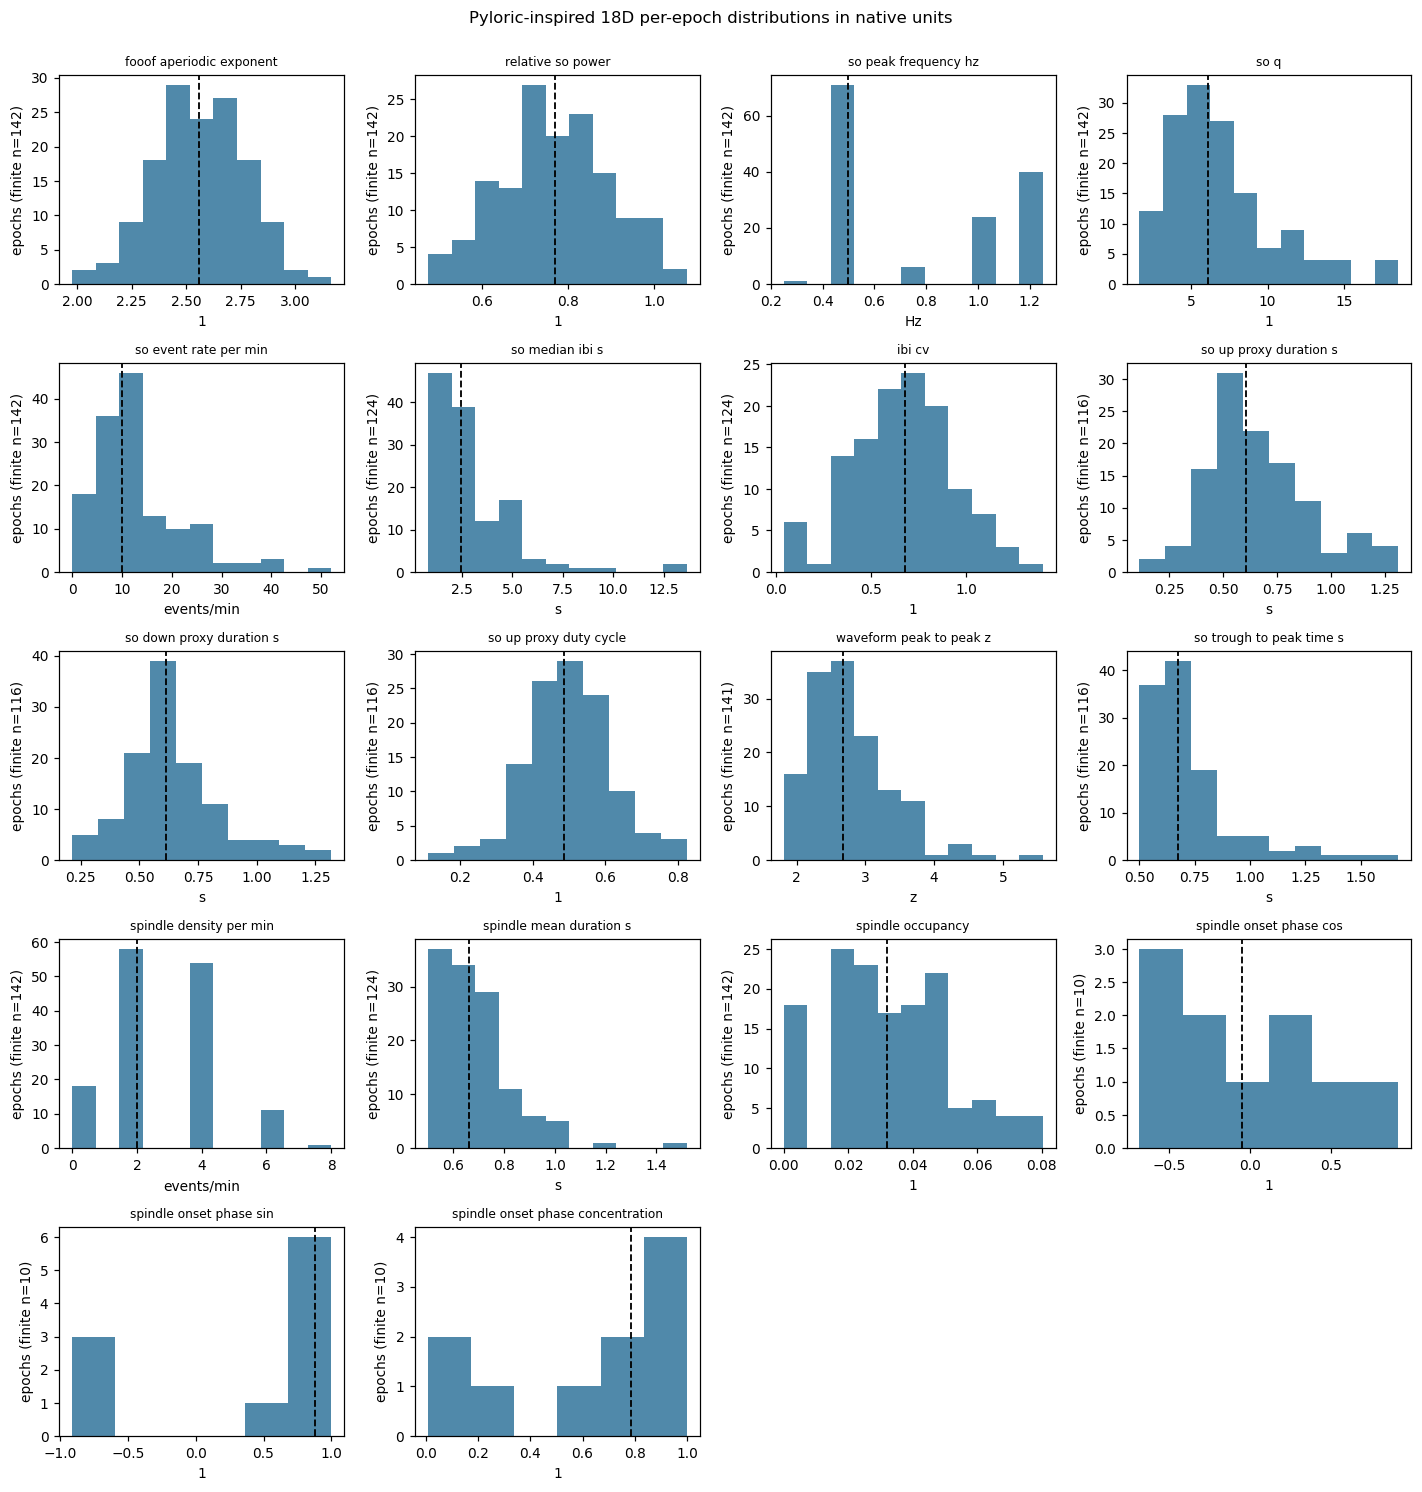

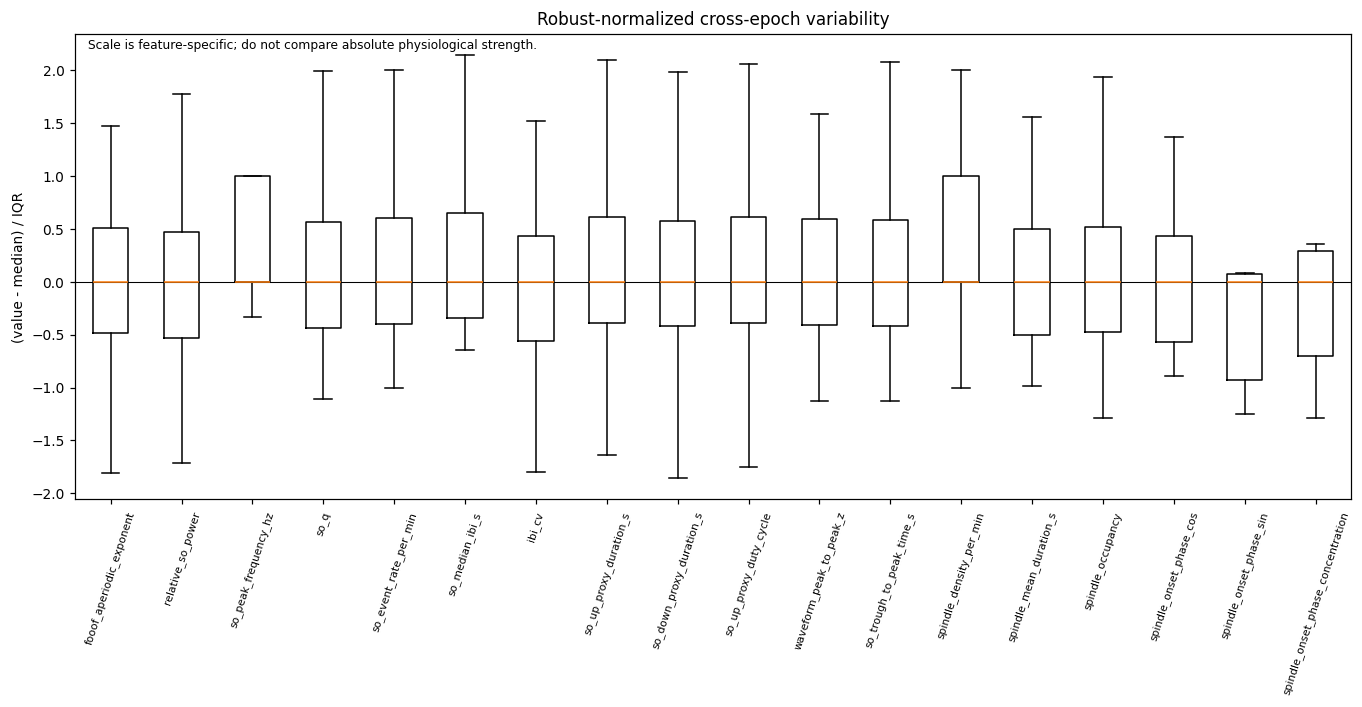

,field_name,finite_epoch_count,missing_fraction,median,q25,q75,iqr,robust_outlier_sensitivity,near_constant,redundant_with,recommendation
0,fooof_aperiodic_exponent,142,0.000000,2.559156,2.419244,2.706804,0.287560,0.008822,False,,suitable for inference candidacy audit
1,relative_so_power,142,0.000000,0.769972,0.678304,0.850703,0.172399,0.000968,False,,suitable for inference candidacy audit
2,so_peak_frequency_hz,142,0.000000,0.500000,0.500000,1.250000,0.750000,0.406103,False,,suitable for inference candidacy audit
3,so_q,142,0.000000,6.125524,4.359816,8.403972,4.044156,0.187532,False,,suitable for inference candidacy audit
4,so_event_rate_per_min,142,0.000000,10.000000,6.000000,16.000000,10.000000,0.311268,False,,suitable for inference candidacy audit
5,so_median_ibi_s,124,0.126761,2.452500,1.570000,4.113750,2.543750,0.214885,False,,suitable for inference candidacy audit
6,ibi_cv,124,0.126761,0.679044,0.478069,0.834141,0.356072,0.024051,False,,suitable for inference candidacy audit
7,so_up_proxy_duration_s,116,0.183099,0.606530,0.489955,0.790530,0.300575,0.169388,False,,suitable as observable proxy candidate; mappin...
8,so_down_proxy_duration_s,116,0.183099,0.611617,0.531578,0.721334,0.189756,0.169482,False,,suitable as observable proxy candidate; mappin...
9,so_up_proxy_duty_cycle,116,0.183099,0.487025,0.429630,0.577153,0.147523,0.089488,False,,suitable as observable proxy candidate; mappin...


In [7]:
distribution_metadata = render_and_save(
    '03_feature_distributions', plot_feature_distributions, result
)
variability_metadata = render_and_save(
    '04_robust_variability', plot_robust_variability, result
)
display(result.stability_audit)

## Redundancy and stability audit

Pairwise-complete Spearman correlation is displayed with its valid-pair count. Structural dependencies are expected: SO rate is approximately inverse IBI, duty cycle is derived from UP/DOWN proxy durations, and spindle occupancy is approximately density times duration. Different names are not independent evidence.

### Block 08 — Spearman redundancy 与 valid-pair support

**科学问题：**  
18 个字段在 retained epochs 上是否提供彼此不同的信息，还是只是同一节律结构的不同表达？

**方法：**
- Spearman correlation 对各 feature 的 rank 做相关，能识别单调但非线性的关系，且比 Pearson 对极端值更稳健；
- 每一对 feature 只用两者都有限的 epoch；
- `valid_pair_count` 单独显示每个相关系数实际用了多少 epoch；
- 当前审计用 $|\rho|\ge0.90$ 且 pair count 达到配置要求标记明显 redundancy。

**左图：Spearman heatmap**
- 横纵轴都是 18 个字段；
- 红色接近 +1，蓝色接近 -1，浅色接近 0；
- 对角线恒为 1，不提供科学信息；
- 高相关不证明因果或同一机制，但说明它们不应被当作完全独立 likelihood evidence。

**右图：valid pair count**
- 颜色表示同时有限的 epoch 数，不是相关强度；
- event-conditioned phase 的行/列支持较少，相关估计更不稳定；
- 只有在 pair count 足够时才应解释 $\rho$。

**预期结构关系：**

$$
\mathrm{SO\ rate}\approx\frac{60}{\mathrm{IBI}},
$$

$$
\mathrm{UP\ duty}=\frac{T_{\mathrm{UP}}}
{T_{\mathrm{UP}}+T_{\mathrm{DOWN}}},
$$

$$
\mathrm{spindle\ occupancy}
\approx\frac{\mathrm{density/min}\times\mathrm{duration/s}}{60}.
$$

当前执行中 spindle density 与 occupancy 的 Spearman $\rho$ 约为 0.92（`n=142`），应视作明显冗余。cos/sin 也共同编码一个 angular degree of freedom；即使其跨 epoch Spearman 不高，也不能当成两个独立机制。

**输出不能说明什么：**  
相关矩阵不能证明哪个 feature 更接近真实生理机制，也不能替代 prior predictive support check。它只帮助选择更紧凑、数值稳定且不过度重复的未来 summary contract。

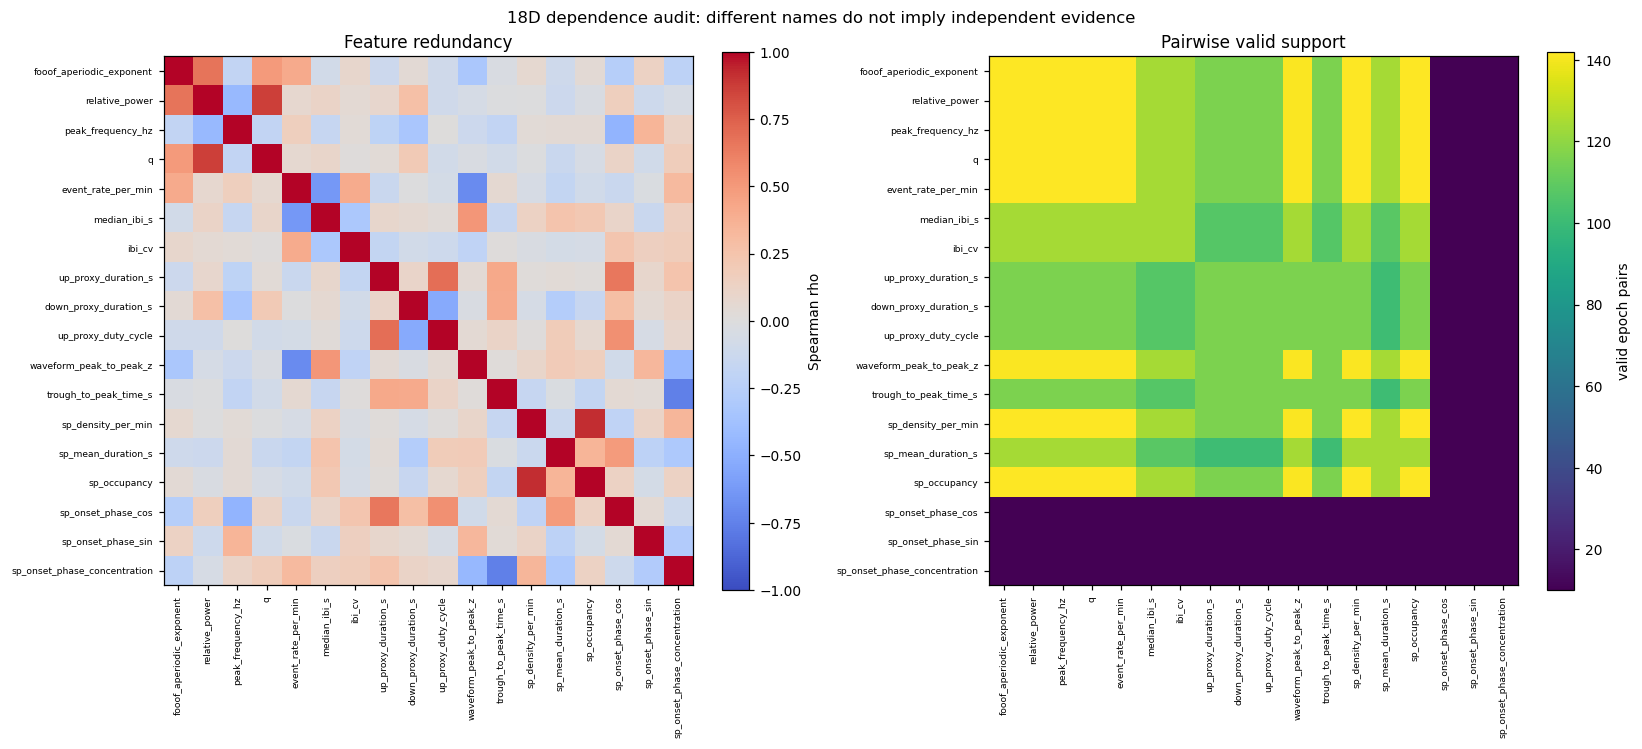

{'figure_id': 'redundancy_heatmap',
 'spearman_method': 'pairwise complete Spearman correlation',
 'structural_relations': ['SO rate approximately 60 / IBI',
  'UP-proxy duty = UP / (UP + DOWN)',
  'spindle occupancy approximately density * duration / 60']}

,field_name,missing_fraction,iqr,redundant_with,recommendation
0,fooof_aperiodic_exponent,0.000000,0.287560,,suitable for inference candidacy audit
1,relative_so_power,0.000000,0.172399,,suitable for inference candidacy audit
2,so_peak_frequency_hz,0.000000,0.750000,,suitable for inference candidacy audit
3,so_q,0.000000,4.044156,,suitable for inference candidacy audit
4,so_event_rate_per_min,0.000000,10.000000,,suitable for inference candidacy audit
5,so_median_ibi_s,0.126761,2.543750,,suitable for inference candidacy audit
6,ibi_cv,0.126761,0.356072,,suitable for inference candidacy audit
7,so_up_proxy_duration_s,0.183099,0.300575,,suitable as observable proxy candidate; mappin...
8,so_down_proxy_duration_s,0.183099,0.189756,,suitable as observable proxy candidate; mappin...
9,so_up_proxy_duty_cycle,0.183099,0.147523,,suitable as observable proxy candidate; mappin...


In [8]:
redundancy_metadata = render_and_save(
    '05_redundancy_heatmap', plot_redundancy_heatmap, result
)
display(redundancy_metadata)
display(result.stability_audit[['field_name', 'missing_fraction', 'iqr', 'redundant_with', 'recommendation']])

## SO temporal morphology: EEG-positive/negative phase proxies

For each accepted upstream SO event, the algorithm finds a complete positive-to-negative, negative-to-positive, and subsequent positive-to-negative zero-crossing sequence entirely inside one 30-second epoch. As-recorded Fpz-Cz negative phase is named DOWN-proxy and positive phase UP-proxy. These observable-level proxies are not neuronal membrane-potential states and cannot be directly equated to simulator-internal cortical UP/DOWN durations.

Duty cycle is `UP-proxy / (UP-proxy + DOWN-proxy)`. Boundary-truncated, polarity-incompatible, and unsupported cycles are invalid with explicit reasons.

### Block 09 — 完整 SO cycle、UP/DOWN proxy 与波形形态

**科学目的：**  
从接受的 SO detector events 中进一步提取一个完全位于同一 30 s epoch 内的负相位/正相位 cycle，并显示 trough、peak、duration proxy 与 aggregate trough-centered morphology。

**算法直观图：**
1. 在 0.2–4 Hz filtered EEG 中定位 upstream detector 的 trough 和随后 peak；
2. trough 前寻找 positive-to-negative zero crossing；
3. trough 后寻找第一个 negative-to-positive crossing；
4. 再寻找紧邻的 positive-to-negative crossing；
5. detector peak 必须落在这段紧邻正相位内；
6. 任一 crossing 越过 epoch 边界、polarity 不符或 cycle duration 超范围则记 invalid reason。

**左图怎样读：**
- 横轴：原生 epoch 内时间，s；
- 纵轴：0.2–4 Hz Fpz-Cz，µV；
- 红点：negative trough；绿点：随后 positive peak；
- 红色阴影：negative / DOWN-proxy duration；
- 绿色阴影：positive / UP-proxy duration；
- 阴影必须在零交叉处结束，不能吞入多个振荡周期。

**右图怎样读：**
- 横轴：相对 detected trough 的时间，s；0 s 虚线为 trough；
- 纵轴：每个 event window 自身 z-score 后的 EEG；
- 紫线：891 个完整 trough-centered waveform 的 aggregate mean；阴影为 SEM；
- 因为单位是 z，它反映形态而非绝对 µV。

**当前支持与 invalid reasons：**  
保守 cycle 规则产生约 322 个完整 cycles、116 个有效 epochs。大量 upstream events 被标记为 `detected_up_peak_outside_immediate_positive_phase`，说明 upstream half-wave detector 的 peak 并不总落在紧邻正相位内；这些事件不能用于本 proxy duration。

**Reviewer note / Potential issue：**
- “UP/DOWN”命名受 scalp polarity、reference 和 montage 影响，只是 observable proxy，不是 neuronal membrane state；
- 保守完整-cycle 条件可能选择更规则的波形，造成 selection bias；
- duration 和 duty 对 band/filter/zero-crossing 定义敏感。在与 simulator 比较前必须定义 observable mapping，而不能直接拿 cortical firing-rate state duration 对比。

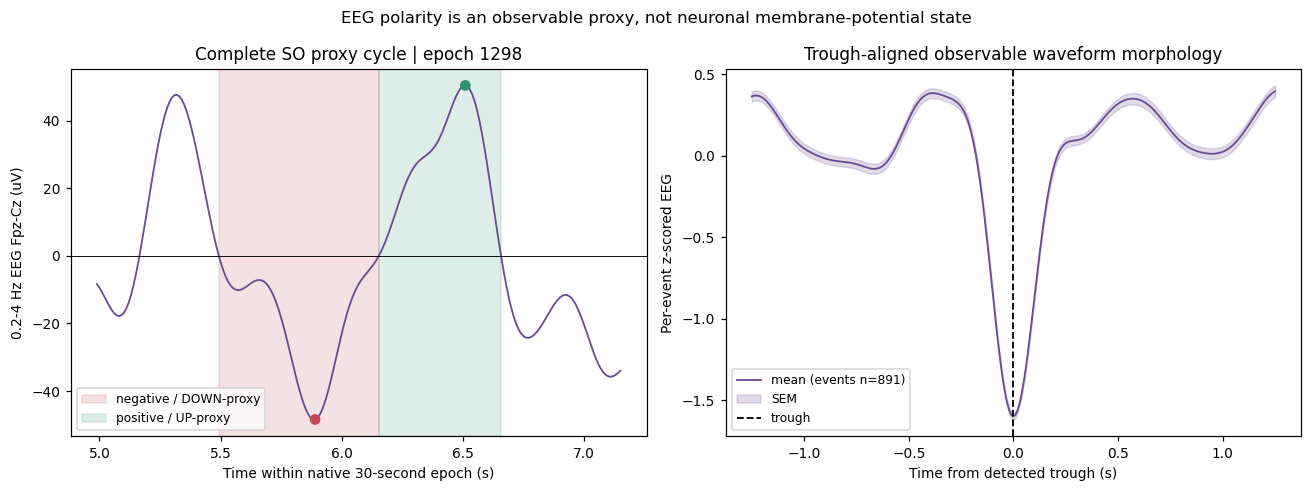

{'figure_id': 'so_proxy_morphology',
 'representative_epoch': 1298,
 'valid_cycle_count': 322,
 'invalid_cycle_count': 609,
 'invalid_reason_counts': {'detected_up_peak_outside_immediate_positive_phase': 580,
  'polarity_convention_not_satisfied': 12,
  'incomplete_cycle_at_left_epoch_boundary': 12,
  'incomplete_cycle_at_right_epoch_boundary': 5},
 'polarity_convention': 'as-recorded Fpz-Cz; negative phase is DOWN-proxy and positive phase is UP-proxy',
 'up_proxy_duration_s': 0.5041527065698267,
 'down_proxy_duration_s': 0.6605086393516819}

,event_count
invalid_reason,
detected_up_peak_outside_immediate_positive_phase,580
None,322
polarity_convention_not_satisfied,12
incomplete_cycle_at_left_epoch_boundary,12
incomplete_cycle_at_right_epoch_boundary,5


In [9]:
so_proxy_metadata = render_and_save(
    '06_so_proxy_morphology', plot_so_proxy_morphology, bundle, result
)
display(so_proxy_metadata)
display(result.diagnostics['so_proxy_cycles']['invalid_reason'].value_counts(dropna=False).to_frame('event_count'))

## Observable spindle activity and occupancy

The existing per-epoch 11-15 Hz moving-RMS detector is reused without threshold tuning. Overlapping accepted intervals are unioned before occupancy is computed. This detector remains provisional, is not V8a internal T13, and requires independent calibration before any spindle field is promoted into fitting.

### Block 10 — Observable spindle detector、零事件语义与 occupancy

**科学问题：**  
在真实 Fpz-Cz retained N3 上，当前 provisional detector 检出哪些 11–15 Hz spindle-like events，它们的密度、持续时间和时间占比如何？

**detector 流程：**
1. 每个 30 s epoch 独立做 11–15 Hz、四阶 Butterworth 零相位滤波；
2. 用 0.2 s moving RMS 得到 amplitude envelope；
3. 每个 epoch 的 threshold 为 envelope mean + 1.5 SD；
4. 合并间隔小于 0.1 s 的候选区间；
5. 只保留 duration 0.5–3.0 s 的 events。

**三层图怎样读：**
- 上：原始 Fpz-Cz µV；观察 event 是否伴随明显 artifact；
- 中：11–15 Hz band-passed EEG µV；持续振荡应落在橙色 event 阴影；
- 下：RMS envelope µV；红色虚线是该 epoch threshold，阴影区间应超过 threshold；
- 横轴全部是同一原生 0–30 s epoch，阴影不能跨边界。

**三个 spindle 指标：**
- density = events / valid minutes；有效 0-event epoch 可为 0；
- mean duration = detected events 的平均秒数；0 events 时没有可平均对象，必须 NaN；
- occupancy = 合并重叠 event intervals 后的 union duration / valid duration，范围 `[0,1]`。

代码中的三个 assert 正是在区分“真实 0”与“undefined”：zero-event epoch 的 density/occupancy 为 0，但 mean duration 为 NaN。当前约有 203 个 events；约 18 个 detector-valid retained epochs 是 0-event。

**科学边界与限制：**
- threshold 按 epoch 自适应，有利于抵抗基线变化，但也可能使不同 epoch 的绝对 amplitude criterion 不一致；
- 本 detector 尚未完成跨信号/跨实现校准，保留 `provisional`；
- 它是 real-EEG observable-channel detector，不是 V8a internal T13，也不能直接套用 thalamic T8/T12 名称；
- spindle density、duration 和 occupancy 高度相关，应优先 held out，而不是全部放进 fitting。

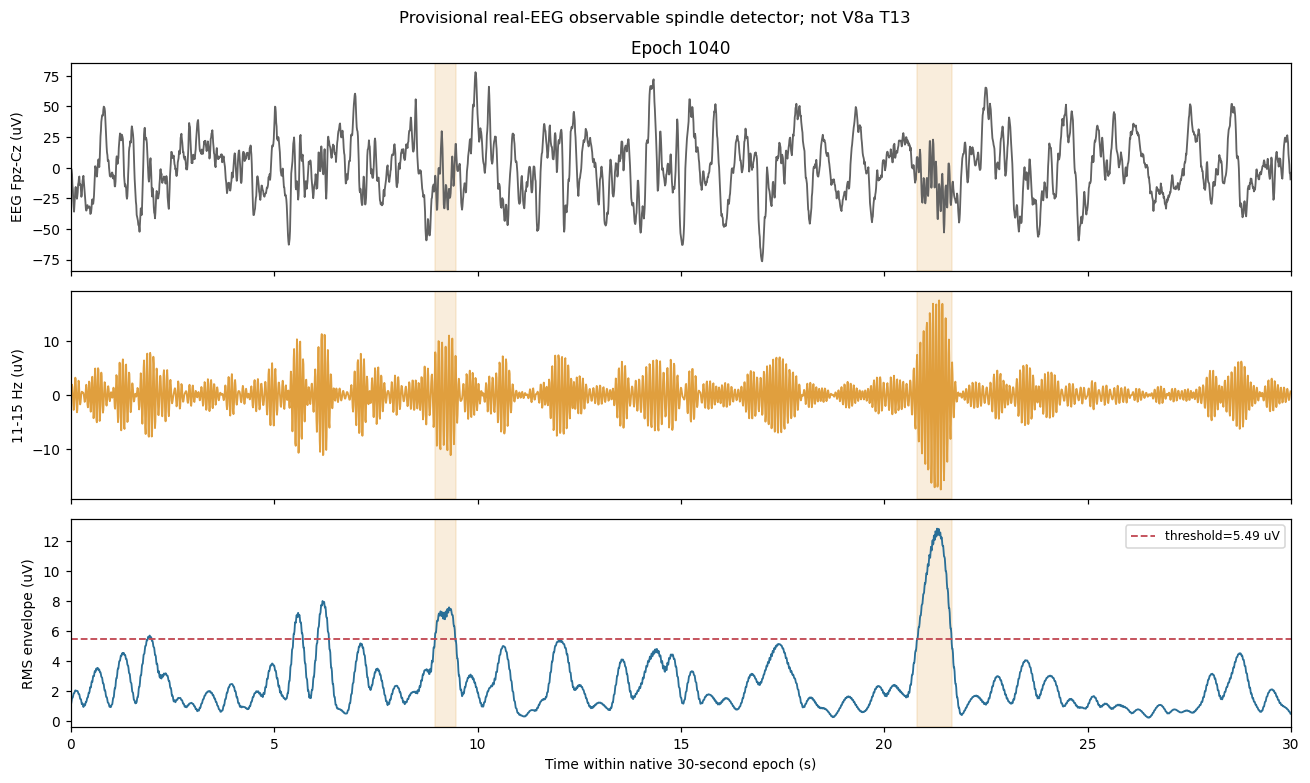

{'figure_id': 'spindle_detection',
 'representative_epoch': 1040,
 'event_count': 2,
 'threshold_uv': 5.488779161407835,
 'parameters': {'filter': 'scipy.signal.butter+sosfiltfilt, per epoch',
  'filter_order': 4,
  'band_hz': (11.0, 15.0),
  'envelope': 'moving RMS',
  'rms_window_s': 0.2,
  'threshold': 'per-epoch mean + 1.5 SD',
  'duration_s': (0.5, 3.0),
  'merge_gap_s': 0.1},
 'status': 'provisional_held_out_ppc_candidate'}

valid zero-event epochs: 18


In [10]:
spindle_metadata = render_and_save(
    '07_spindle_detection', plot_spindle_detection, bundle, result
)
display(spindle_metadata)
zero_spindle = result.per_epoch_features['spindle_event_count'].eq(0)
assert (result.per_epoch_features.loc[zero_spindle, 'spindle_density_per_min'] == 0).all()
assert (result.per_epoch_features.loc[zero_spindle, 'spindle_occupancy'] == 0).all()
assert result.per_epoch_features.loc[zero_spindle, 'spindle_mean_duration_s'].isna().all()
print('valid zero-event epochs:', int(zero_spindle.sum()))

## Event-conditioned SO-spindle coordination

Each spindle onset is paired only when it lies between two accepted SO troughs in the same epoch and the trough-to-trough cycle is within the predeclared support. The current trough is phase 0 and the next trough phase 2*pi. Circular mean cosine/sine and resultant length R form the three core coordinates; the raw mean angle is auxiliary and is not double-counted in 18D. This statistic is distinct from continuous Tort PAC.

### Block 11 — Event-conditioned SO–spindle pairing 与 circular statistics

**科学目的：**  
不再用连续 Tort PAC 的所有 samples，而是问一个事件级问题：检测到的 spindle onset 落在相邻 SO trough-to-trough cycle 的什么位置？

**配对规则：**
- SO trough 与 spindle onset 必须在同一 30 s epoch；
- onset 必须位于当前 trough 与下一 trough 之间；
- trough-to-trough duration 必须在配置的 0.5–5.0 s support；
- phase 定义为

$$
\theta=2\pi\frac{t_{\mathrm{onset}}-t_{\mathrm{trough},i}}
{t_{\mathrm{trough},i+1}-t_{\mathrm{trough},i}},
$$

当前 trough 为 0 rad，下一 trough 为 $2\pi$；
- aggregate 至少需要 10 个 paired events；per-epoch circular feature 至少需要 2 个 pairs。

**event-pairing 图：**
- 上图纵轴为 0.2–4 Hz EEG µV，下图为 11–15 Hz RMS µV；
- 灰色虚线是 cycle 起始 trough，淡紫阴影是该 trough-to-trough cycle；
- 红色虚线是 spindle onset，旁边标注 onset phase；
- 图只说明时间几何配对，不证明 spindle 由该 SO cycle 引起。

**circular plot：**
- 角度是 onset phase，半径柱高是该 phase bin 的 event count；
- 0° 与 360° 是同一点，所以不能用线性平均；
- 红色箭头方向是 circular mean phase，长度按 concentration $R$ 缩放；
- 当前约 52 个 paired events、42 个有配对支持的 epochs，$R\approx0.198$，表示方向集中度较弱。

**为什么用 sin/cos：**  
`cos(mean phase)` 和 `sin(mean phase)` 避免角度在 $-\pi/\pi$ 边界跳变；但它们共同描述一个角度，不能与 raw phase 一起作为三维独立输入。`R` 是另一个维度，描述集中程度。

**事件不足的语义：**  
没有足够 pairs 时 mean direction 和 concentration 都 undefined，应返回 NaN/warning。填 0 会把“没有证据”误写成“mean phase 为 0 且完全分散”。

**与 PAC 的区别：**  
continuous PAC 使用每个 sample 的 SO phase 和 spindle-band amplitude；本 block 只使用 detected onset events。PAC MI 很弱时，其 preferred phase 可能由噪声决定；event-conditioned phase 也必须结合 event count 和 $R$ 解读。

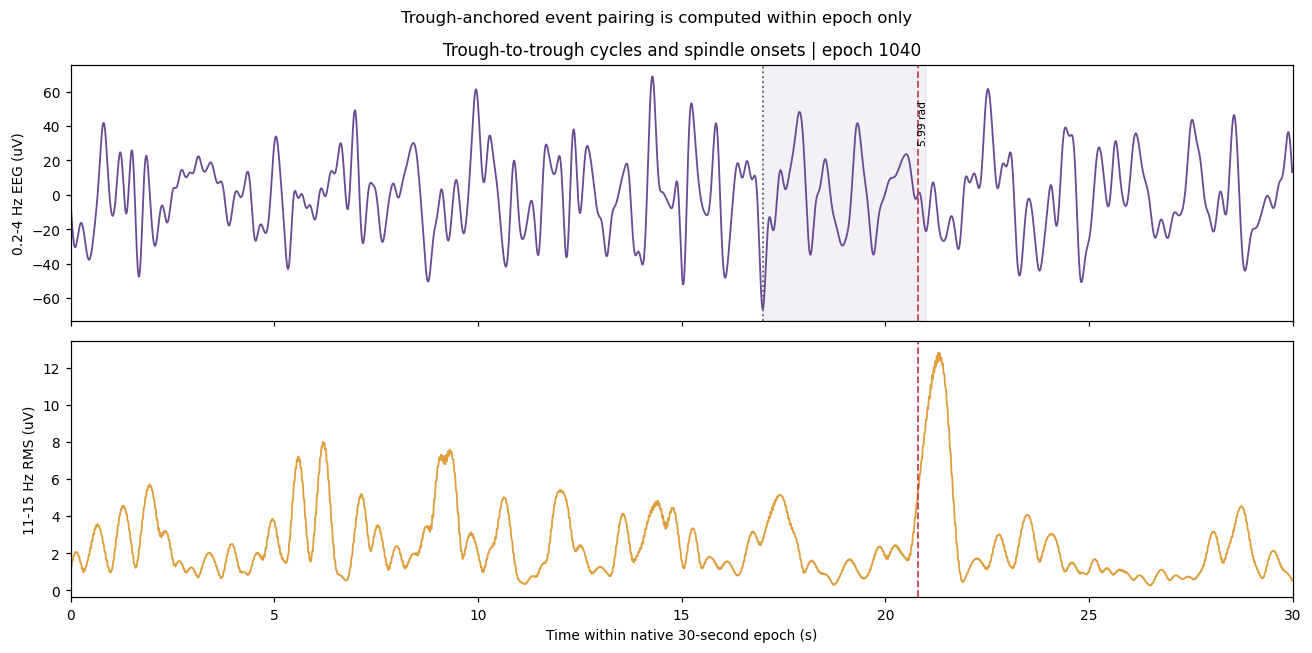

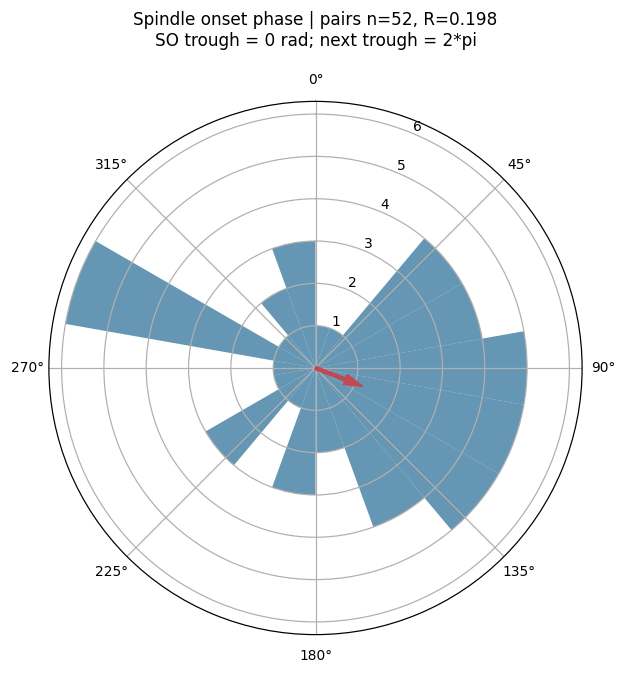

{'figure_id': 'event_pairing',
 'representative_epoch': 1040,
 'paired_event_count': 1,
 'phase_convention': 'current SO trough is 0 rad and the next trough is 2*pi',
 'cycle_duration_support_s': [0.5, 5.0]}

{'figure_id': 'onset_phase_circular',
 'paired_event_count': 52,
 'mean_angle_rad': 1.9407722418331472,
 'mean_cos': -0.3615929767916234,
 'mean_sin': 0.9323360548294657,
 'concentration': 0.1981992356581439,
 'warning': 'Interpret mean phase with concentration; this is not continuous PAC preferred phase.'}

In [11]:
pairing_metadata = render_and_save(
    '08_event_pairing', plot_event_pairing, bundle, result
)
circular_metadata = render_and_save(
    '09_onset_phase_circular', plot_onset_phase_circular, result
)
display(pairing_metadata)
display(circular_metadata)

## Metric support and intended roles

Metric-specific missingness reflects event support or detector validity, not global QC rejection. Roles are initial scientific safeguards, not fitting decisions. Mechanism diagnostics remain outside the numerical 18D observation.

### Block 12 — Valid support、missingness、角色图与 auxiliary diagnostics

**科学目的：**  
把“有一个 aggregate 数值”拆解成它由多少 epochs/events 支持，并明确哪些量属于 inference、held-out 或 mechanism diagnostic。

**support/missingness 图：**
- 左图横轴：每个 feature 有有限值的 retained epoch 数；
- 右图横轴：retained epochs 中的 missing fraction，并标注 aggregate valid event count；
- missing 不等于 global rejected，而是某项统计在 retained epoch 内没有足够支持；
- phase 三项 per-epoch missing fraction 约 0.93，因为每个 epoch 需要至少两个 pairs；aggregate 仍可由跨 epoch 共 52 个 pairs 计算。这说明 aggregate-valid 与 per-epoch-dense 是不同概念。

**role map：**
- 横轴：finite epoch fraction；
- 蓝色：`inference_summary_candidate`；
- 橙色：`held_out_ppc_candidate`；
- bar 内文字是稳定性/冗余审计后的 recommendation；
- bar 长度反映支持率，不表示 feature 的生理效应大小或拟合权重。

**`auxiliary_diagnostics` 怎样读：**
- continuous `pac_mi`、preferred phase 和 `pac_up_down_ratio` 作为辅助诊断，不进入新的 18D；
- 当前 PAC MI 约 0.0002，耦合很弱，此时 preferred phase 对噪声、bin、band 和 filter 选择敏感；
- `T11_lag_ms` 是 legacy misnomer；`pac_up_down_ratio` 不是时间 lag；
- T9–T13 等 model-side quantities 在真实单通道 EEG 中标为 `not observable`，不伪造数值。

**三种角色的解释边界：**
- inference candidate 仍需 prior predictive support、simulator observable mapping 与 redundancy selection；
- held-out candidate 在没有 posterior estimator 时只能称 PPC-like candidate，不能叫正式 posterior predictive check；
- mechanism diagnostic 用于理解机制或实现，不应混入 observation fitting vector。

**怎样判断 support 是否足够：**  
同时看 finite epoch fraction、valid event count、invalid reasons、跨 epoch spread 和 detector calibration。一个数值有限不代表其 sampling variability 很小；低 event count 时应优先保留为 held out。

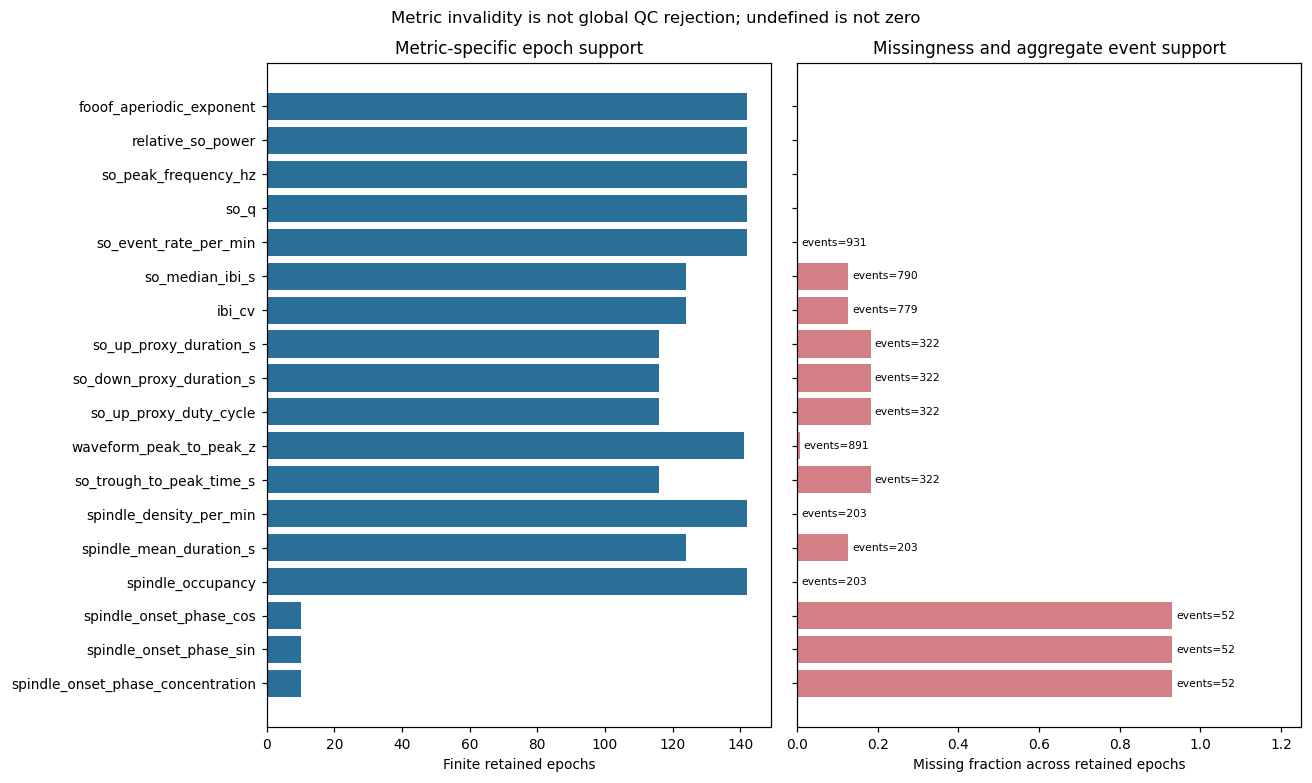

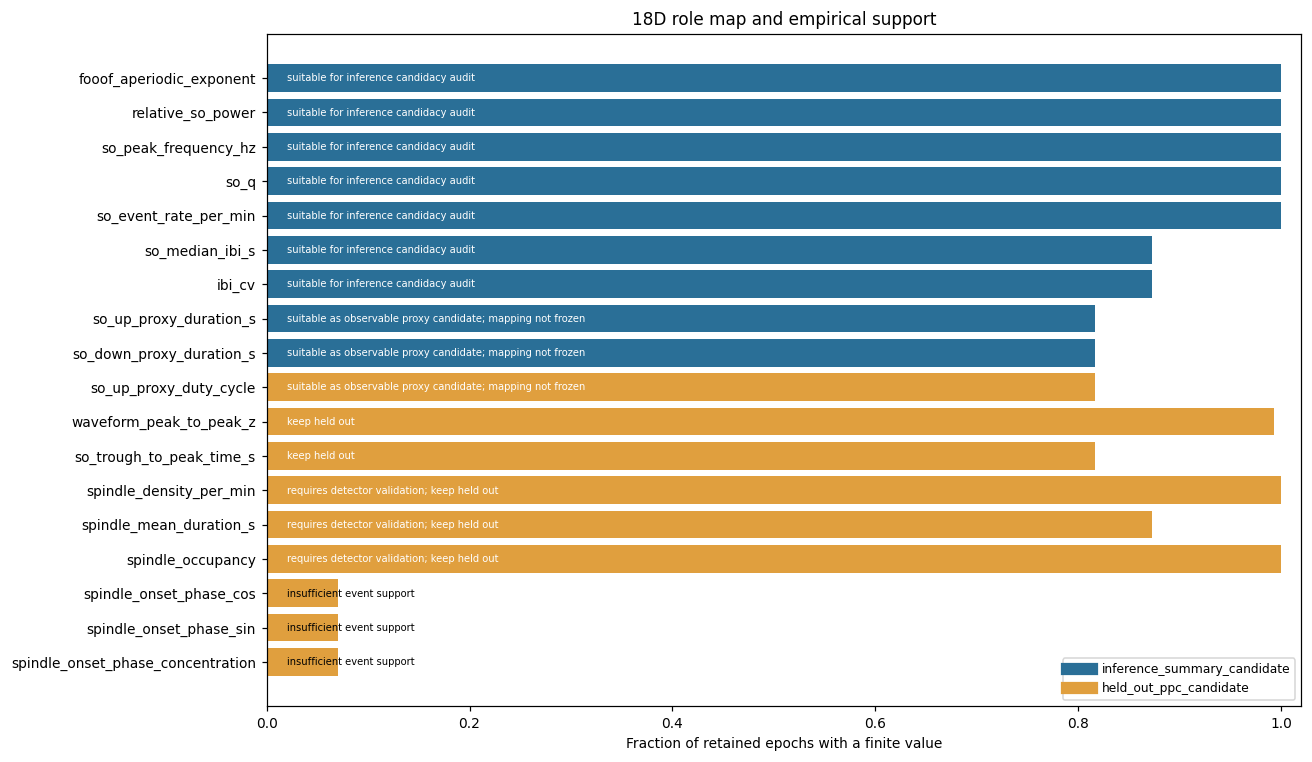

,field_name,value,unit,intended_role,observability,warning
0,continuous_pac_mi,0.000204,1,mechanism_diagnostic,single-channel EEG auxiliary diagnostic,Continuous Tort PAC is not event-conditioned o...
1,continuous_pac_preferred_phase_rad,1.221730,rad,mechanism_diagnostic,single-channel EEG auxiliary diagnostic,Not included in the 18D core; sin/cos/onset ph...
2,continuous_pac_up_down_ratio,1.034337,1,mechanism_diagnostic,single-channel EEG auxiliary diagnostic,Semantic field name only. Legacy T11_lag_ms is...
3,event_conditioned_mean_phase_rad,1.940772,rad,mechanism_diagnostic,single-channel EEG event-conditioned auxiliary,Auxiliary angle only; excluded from the 18D co...
4,T9_model_internal_pac,NaN,not_observable,mechanism_diagnostic,not observable from single-channel Fpz-Cz EEG,model-side coupling quantity; no EEG value is ...
5,T10_model_internal_phase,NaN,not_observable,mechanism_diagnostic,not observable from single-channel Fpz-Cz EEG,model-side phase quantity; no EEG value is fab...
6,T11_model_directional_lag,NaN,not_observable,mechanism_diagnostic,not observable from single-channel Fpz-Cz EEG,model-side directional timing quantity; no EEG...
7,T12_thalamic_spindle,NaN,not_observable,mechanism_diagnostic,not observable from single-channel Fpz-Cz EEG,model-side thalamic spindle detector; no EEG v...
8,T13_cortex_visible_spindle,NaN,not_observable,mechanism_diagnostic,not observable from single-channel Fpz-Cz EEG,V8a model audit detector; no EEG value is fabr...


{'figure_id': 'support_missingness',
 'finite_epoch_count': {'fooof_aperiodic_exponent': 142,
  'relative_so_power': 142,
  'so_peak_frequency_hz': 142,
  'so_q': 142,
  'so_event_rate_per_min': 142,
  'so_median_ibi_s': 124,
  'ibi_cv': 124,
  'so_up_proxy_duration_s': 116,
  'so_down_proxy_duration_s': 116,
  'so_up_proxy_duty_cycle': 116,
  'waveform_peak_to_peak_z': 141,
  'so_trough_to_peak_time_s': 116,
  'spindle_density_per_min': 142,
  'spindle_mean_duration_s': 124,
  'spindle_occupancy': 142,
  'spindle_onset_phase_cos': 10,
  'spindle_onset_phase_sin': 10,
  'spindle_onset_phase_concentration': 10},
 'missing_fraction': {'fooof_aperiodic_exponent': 0.0,
  'relative_so_power': 0.0,
  'so_peak_frequency_hz': 0.0,
  'so_q': 0.0,
  'so_event_rate_per_min': 0.0,
  'so_median_ibi_s': 0.12676056338028174,
  'ibi_cv': 0.12676056338028174,
  'so_up_proxy_duration_s': 0.18309859154929575,
  'so_down_proxy_duration_s': 0.18309859154929575,
  'so_up_proxy_duty_cycle': 0.183098591549295

{'figure_id': 'role_map',
 'role_counts': {'inference_summary_candidate': 9,
  'held_out_ppc_candidate': 9},
 'warning': 'Candidate roles are not frozen fitting decisions.'}

In [12]:
support_metadata = render_and_save(
    '10_support_missingness', plot_support_and_missingness, result
)
role_metadata = render_and_save('11_role_map', plot_role_map, result)
display(result.auxiliary_diagnostics)
display(support_metadata)
display(role_metadata)

## Regression against the existing Observation notebook

Overlapping aggregates reuse the existing implementation and must agree at numerical tolerance. Median IBI, proxy durations/duty, occupancy, and onset-phase statistics are new and therefore have no old counterpart. Continuous PAC remains auxiliary; `T11_lag_ms` is a legacy misnomer and is never interpreted as a lag.

### Block 13 — 与原 `01_observation.ipynb` 的重叠指标回归

**工程与科学目的：**  
Pyloric-inspired 扩展应增加新 feature，而不能无说明地改变旧 Observation target。此表逐项比较旧值与新 pipeline 中复用的值。

**表格列：**
- `old_field_name` / `new_field_name`：字段对应关系；
- `old_value` / `new_value`；
- `absolute_difference`、`relative_difference`；
- `tolerance`：允许的数值误差；
- `status`：pass/warning/fail；
- `difference_reason`：是完全复用、辅助重命名，还是定义变化。

重点覆盖 aperiodic exponent、relative SO power、SO peak、SO Q、SO event rate、IBI_CV、waveform peak-to-peak、spindle density/duration 和 continuous PAC 辅助量。当前执行结果为 12 pass、最大 absolute difference 为 0。

**assert 的意义：**  
任何 `fail` 都会停止，迫使研究者定位 preprocessing、aggregation、detector、valid population 或 bug fix 的差异，不能静默接受 target 漂移。

**能说明什么 / 不能说明什么：**
- pass 说明新 notebook 对重叠字段保持数值兼容；
- pass 不证明旧算法生理正确，因为 old/new 可能共享同一偏差；
- 新增 median IBI、proxy duration/duty、occupancy 和 event-conditioned timing 没有旧字段，因此不在此回归表中；
- 若未来有经过说明的 bug fix，合理结果可以变化，但必须把 reason、旧值和新值留在审计记录中。

In [13]:
display(result.old_vs_new_regression)
assert not result.old_vs_new_regression['status'].eq('fail').any()
print(result.old_vs_new_regression['status'].value_counts().to_dict())

,old_field_name,new_field_name,old_value,new_value,absolute_difference,relative_difference,tolerance,status,difference_reason
0,fooof_aperiodic_exponent,fooof_aperiodic_exponent,2.558807,2.558807,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
1,relative_so_power,relative_so_power,0.777428,0.777428,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
2,so_peak_frequency_hz,so_peak_frequency_hz,0.500000,0.500000,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
3,so_q,so_q,4.869293,4.869293,0.0,0.0,1.000000e-10,pass,exact upstream aggregate reuse
4,so_event_rate_per_min,so_event_rate_per_min,13.112676,13.112676,0.0,0.0,1.000000e-10,pass,exact upstream detector and aggregate reuse
5,ibi_cv,ibi_cv,1.011715,1.011715,0.0,0.0,1.000000e-10,pass,exact upstream pooled-within-epoch definition ...
6,waveform_peak_to_peak_z,waveform_peak_to_peak_z,1.993695,1.993695,0.0,0.0,1.000000e-10,pass,exact upstream aggregate waveform reuse
7,spindle_density_per_min,spindle_density_per_min,2.859155,2.859155,0.0,0.0,1.000000e-10,pass,exact upstream detector and aggregate reuse
8,spindle_mean_duration_s,spindle_mean_duration_s,0.676798,0.676798,0.0,0.0,1.000000e-10,pass,exact upstream event-duration aggregate reuse
9,pac_mi,continuous_pac_mi,0.000204,0.000204,0.0,0.0,1.000000e-10,pass,retained outside 18D as an unchanged auxiliary...


{'pass': 12}


## Publication-safe exports

Exports contain aggregate values, per-epoch features, epoch accounting, dictionaries, validation tables, and figures. No raw or filtered EEG arrays, EDF copies, simulator records, or machine-absolute paths are serialized.

### Block 14 — Publication-safe artifacts 与 figure manifest

**目的：**  
把 notebook 中已经独立生成并验证的 11 张图和安全表格导出到统一目录，同时保证不序列化完整 EEG arrays、EDF 副本或机器绝对路径。

**代码逻辑：**
1. 将 Block 04–12 累积的 `figure_records` 转成 `figure_manifest`；
2. 断言恰好 11 张图，防止某个 plot cell 被跳过；
3. `write_publication_safe_artifacts(...)` 写出 summary、per-epoch features、epoch ledger、feature dictionary、regression、stability、validation 和 manifest；
4. manifest 只显示相对 `figures/*.png/pdf` 路径；
5. 输出目录 `S4_sbi/outputs/pyloric_inspired_observation/` 服从现有 gitignore。

**主要文件：**
- `pyloric_inspired_18d_summary.csv/json`；
- `pyloric_inspired_per_epoch_features.csv`；
- `epoch_ledger.csv`；
- `feature_dictionary.csv`；
- `old_vs_new_regression.csv`；
- `validation_report.md`；
- 11 组 PNG/PDF。

**为什么 per-epoch table 可以导出但 raw EEG 不可以：**  
per-epoch features 是压缩后的研究 metadata，用于 missingness、correlation 和复现；完整 3000-sample epoch array 会形成原始 EEG 副本，增加隐私、体积和误用风险。

**运行顺序注意：**  
`figure_records` 依赖前面的 plot cells。若只单独运行本 cell，`len==11` assertion 可能失败；这不是科学结果失败，而是 notebook execution order 不完整。Restart and Run All 会按正确顺序建立 manifest。

In [14]:
figure_manifest = pd.DataFrame(figure_records)
assert len(figure_manifest) == 11
written_output = write_publication_safe_artifacts(
    bundle, result, pyloric_config, figure_manifest
)
display(figure_manifest[['figure_id', 'png', 'pdf']])
print('publication-safe output:', written_output.relative_to(ROOT))

,figure_id,png,pdf
0,01_concept_mapping,figures/01_concept_mapping.png,figures/01_concept_mapping.pdf
1,02_epoch_qc_audit,figures/02_epoch_qc_audit.png,figures/02_epoch_qc_audit.pdf
2,03_feature_distributions,figures/03_feature_distributions.png,figures/03_feature_distributions.pdf
3,04_robust_variability,figures/04_robust_variability.png,figures/04_robust_variability.pdf
4,05_redundancy_heatmap,figures/05_redundancy_heatmap.png,figures/05_redundancy_heatmap.pdf
5,06_so_proxy_morphology,figures/06_so_proxy_morphology.png,figures/06_so_proxy_morphology.pdf
6,07_spindle_detection,figures/07_spindle_detection.png,figures/07_spindle_detection.pdf
7,08_event_pairing,figures/08_event_pairing.png,figures/08_event_pairing.pdf
8,09_onset_phase_circular,figures/09_onset_phase_circular.png,figures/09_onset_phase_circular.pdf
9,10_support_missingness,figures/10_support_missingness.png,figures/10_support_missingness.pdf


publication-safe output: S4_sbi\outputs\pyloric_inspired_observation


## Final validation

The final assertions check schema dimensionality, circular-coordinate non-duplication, ledger identities, metric support, bounded coordinates, positive durations, finite-value policy, old/new regression, and artifact existence. Notebook-level JSON, code-cell compilation, kernel, and error-output checks are also performed externally in `neurolib` after Run All.

### Block 15 — 最终 schema、数值范围、artifact 与 execution 验证

**目的：**  
在 notebook 结束前把最关键的不变量转成硬断言，使“看起来生成了表格”升级为可审计的结构验证。

**逐项检查：**
1. `result.validation_checks` 全部通过；
2. summary 恰好 18 行且 field name 唯一；
3. `spindle_onset_phase_rad` 不进入 core，防止 raw angle 与 sin/cos 重复计维；
4. core value 不含 `inf`；
5. duty cycle、occupancy、phase concentration 要么 NaN，要么在 `[0,1]`；
6. 七个必要表格/报告存在且非空；
7. manifest 中每个 PNG/PDF 存在且文件大小超过 1000 bytes，避免空壳文件；
8. 显示所有 validation checks，并打印最终成功标志。

**失败怎样解释：**
- schema 失败：字段重复、缺失或顺序漂移；
- range 失败：公式、aggregation 或单位可能有 bug；
- artifact 失败：上游 plot/export cell 未运行或路径配置错误；
- NaN 本身不一定失败，关键在于是否符合 validity rule 并有 reason；
- error output 不是 warning，不能在 annotated 版本中新增或隐藏。

**验证范围的边界：**  
这些 checks 验证代码契约、数值合法性和产物完整性，但不验证跨受试者泛化、detector sensitivity/specificity、simulator support、parameter identifiability 或 posterior calibration。它们是进入下一阶段前的工程门槛，不是 SBI 已经成功的证据。

当前原 notebook 已在 `neurolib` 中完整执行，code execution count 连续为 1–15，且没有 error output。本 annotated 版本保留这些真实 outputs，不重新执行，也不伪造新的 execution count。

In [15]:
assert result.validation_checks['passed'].all()
assert len(result.summary) == 18 and result.summary['field_name'].nunique() == 18
assert 'spindle_onset_phase_rad' not in set(result.summary['field_name'])
assert not np.isinf(result.summary['value'].to_numpy(float)).any()
for field in ('so_up_proxy_duty_cycle', 'spindle_occupancy', 'spindle_onset_phase_concentration'):
    value = float(result.summary.set_index('field_name').loc[field, 'value'])
    assert np.isnan(value) or 0 <= value <= 1, (field, value)
required_artifacts = [
    'pyloric_inspired_18d_summary.csv',
    'pyloric_inspired_18d_summary.json',
    'pyloric_inspired_per_epoch_features.csv',
    'epoch_ledger.csv',
    'feature_dictionary.csv',
    'old_vs_new_regression.csv',
    'validation_report.md',
]
for name in required_artifacts:
    artifact = OUTPUT_DIR / name
    assert artifact.is_file() and artifact.stat().st_size > 0, artifact
for relative_path in figure_manifest[['png', 'pdf']].to_numpy().flat:
    artifact = OUTPUT_DIR / relative_path
    assert artifact.is_file() and artifact.stat().st_size > 1000, artifact
display(result.validation_checks)
print('VALIDATION PASSED: real SC4001 Pyloric-inspired 18D observation')

,check,passed,detail
0,schema_has_exactly_18_unique_fields,True,"rows=18, unique=18"
1,raw_phase_not_in_core_18d,True,phase is represented by sin/cos; angle is auxi...
2,retained_plus_rejected_equals_all_n3,True,142 + 78 = 220
3,retained_and_rejected_are_disjoint,True,N3 destination sets are mutually exclusive
4,every_rejected_epoch_has_reason,True,rejected=78
5,non_n3_not_counted_as_qc_rejection,True,QC rejection is an N3-only decision
6,per_epoch_rows_equal_retained_n3,True,rows=142
7,no_infinite_core_values,True,undefined=0
8,overlap_regression_has_no_failures,True,{'pass': 12}
9,minimum_paired_event_rule_recorded,True,"global=10, per_epoch=2"


VALIDATION PASSED: real SC4001 Pyloric-inspired 18D observation


## Interpretation and next scientific decision

The expanded library now spans spectral structure, SO rhythm, observable temporal morphology, spindle rate/duration/occupancy, and event-conditioned SO-spindle timing. Correlation, missingness, and deterministic relationships show why all 18 fields should not be inserted into fitting as if independent.

Before a simulator-facing summary contract is frozen, the next review should prioritize: (1) EEG-to-simulator observable mapping for UP/DOWN proxies, (2) independent validation of the provisional spindle detector, (3) sensitivity of event-conditioned timing to the declared pairing support, and (4) redundancy-aware selection among rate, IBI, duty, and occupancy coordinates.

## 阅读总结与下一步

### 1. 从原始 EEG 到 18D 的主链路

`manifest → PSG/hypnogram → 30 s epoch alignment → stage normalization → N3 selection → global peak-to-peak QC → retained epochs → per-epoch PSD/SO/spindle/PAC diagnostics → metric-specific validity → 18D aggregate → redundancy/support/regression audit → publication-safe export`。

任何一步都保留 provenance、单位、参数或 invalid reason。不连续 N3 epochs 从未拼接后再过滤或计算 IBI。

### 2. 当前 inference candidates

`fooof_aperiodic_exponent`、`relative_so_power`、`so_peak_frequency_hz`、`so_q`、`so_event_rate_per_min`、`so_median_ibi_s`、`ibi_cv`、`so_up_proxy_duration_s`、`so_down_proxy_duration_s`。

它们只是 candidate。尤其 UP/DOWN proxy 需要 EEG-to-simulator observable mapping；rate/IBI 需要冗余筛选。

### 3. 更适合 held-out / PPC-like 检查的字段

`so_up_proxy_duty_cycle`、`waveform_peak_to_peak_z`、`so_trough_to_peak_time_s`、spindle density/duration/occupancy、spindle onset phase sin/cos/concentration。当前没有 posterior estimator，因此应称 held-out predictive-check candidate，而不是正式 PPC。

### 4. Mechanism diagnostics

continuous PAC MI、PAC preferred phase、`pac_up_down_ratio` 和 model-side T9–T13 只用于辅助解释。真实单通道 EEG 不能直接观察 thalamic onset、cortex-thalamus directional coupling 或 propagation latency，不能伪造 observation value。

### 5. 明显冗余

- SO rate 与 IBI 近似互为倒数；
- UP duty 由 UP/DOWN durations 决定；
- spindle occupancy 约由 density × duration 决定；
- phase sin/cos 共同编码一个角度；
- spectral power、SO Q 与 aperiodic exponent 也可能相关。

未来 summary contract 应选择信息互补且 simulator 可支持的子集，而不是机械使用全部 18D。

### 6. 依赖 event support 的字段

IBI 需要同一 epoch 内足够 SO intervals；spindle mean duration 需要至少一个 event；phase direction/concentration 需要足够 paired onsets。没有事件、事件不足和真实数值为 0 是三种不同状态。

### 7. 怎样判断一个 summary 是否可信

同时检查：定义和单位是否明确、是否保持 epoch 边界、valid epoch/event count、missing fraction、invalid reasons、跨 epoch spread、detector calibration、对 threshold/filter 的敏感性、与其他字段的 redundancy、旧版回归，以及 simulator prior 是否覆盖 observation。只看一个 aggregate value 不足以建立可信度。

### 8. 下一步怎样进入 SBI

先冻结 observation/simulator 共享的 observable mapping，再用 prior predictive simulation 检查 18D candidate support；依据稳定性和冗余选择紧凑的 `SummaryContractV1`；保留 spindle、phase 和 waveform 等字段作独立 predictive checks。只有训练并验证多个独立 NPE、完成 global/local diagnostics 后，才能进行正式 posterior predictive simulation 和 posterior interpretation。

### 建议优先复习

1. Block 02：epoch alignment、global QC 与 metric-specific validity；
2. Block 03：18D 逐项定义和角色；
3. Block 08：冗余与 valid-pair support；
4. Block 09–11：SO proxy、spindle、event-conditioned circular timing；
5. Block 13：旧版回归为何只能证明兼容性、不能证明生理正确性。